# Fractals

## Gemini

In [1]:
import pandas as pd
from IPython.display import display

# Definition of the configuration variables from your script
config_data = {
    "Variable Name": [
        "MODEL", 
        "TEMPERATURES", 
        "NUM_RUNS", 
        "DAT_BASELINE_RUNS",
        "INTER_CALL_SLEEP", 
        "RETRY_BACKOFF", 
        "IMAGE_DIRS",
        "RESULTS_DIR", 
        "BASELINE_OUTPUT", 
        "MAIN_OUTPUT"
    ],
    "Value in Code": [
        "google/gemini-3.1-pro-preview", 
        "[0.0, 1.0, 1.5]", 
        "10", 
        "10",
        "8", 
        "[30, 60, 120]", 
        "FD135, FD17",
        "results/Gemini-3.1-Pro", 
        "dat_baseline_results.jsonl", 
        "main_results.jsonl"
    ],
    "Simple Explanation": [
        "AI model name used for the experiment",
        "Creativity levels (0.0 = strict, 1.5 = highly creative)",
        "Number of repeated runs per image (Phase 2)",
        "Number of baseline runs (Phase 1)",
        "Seconds to wait between API calls (prevents server overload)",
        "Wait times in seconds if the server fails/disconnects",
        "Folders containing the input images",
        "Main folder where all results are saved",
        "Output file for Phase 1 results",
        "Output file for Phase 2 results"
    ]
}

# Create a Pandas DataFrame
df_config = pd.DataFrame(config_data)

# Apply some basic styling for better readability in Jupyter Notebook
styled_df = df_config.style.set_properties(**{'text-align': 'left'}).set_table_styles(
    [dict(selector='th', props=[('text-align', 'left'), ('font-weight', 'bold'), ('background-color', '#f4f4f4')])]
)

# Display the clean table
display(styled_df)

,Variable Name,Value in Code,Simple Explanation
0,MODEL,google/gemini-3.1-pro-preview,AI model name used for the experiment
1,TEMPERATURES,"[0.0, 1.0, 1.5]","Creativity levels (0.0 = strict, 1.5 = highly creative)"
2,NUM_RUNS,10,Number of repeated runs per image (Phase 2)
3,DAT_BASELINE_RUNS,10,Number of baseline runs (Phase 1)
4,INTER_CALL_SLEEP,8,Seconds to wait between API calls (prevents server overload)
5,RETRY_BACKOFF,"[30, 60, 120]",Wait times in seconds if the server fails/disconnects
6,IMAGE_DIRS,"FD135, FD17",Folders containing the input images
7,RESULTS_DIR,results/Gemini-3.1-Pro,Main folder where all results are saved
8,BASELINE_OUTPUT,dat_baseline_results.jsonl,Output file for Phase 1 results
9,MAIN_OUTPUT,main_results.jsonl,Output file for Phase 2 results


In [2]:
import pandas as pd
from pathlib import Path
from IPython.display import display

# Define the path to the Phase 1 file
BASELINE_PATH = "/Users/precioux/Desktop/Projects/Creativity/code/Server/Fractals/results/Gemini-3.1-Pro/dat_baseline_results.jsonl"

print("Analyzing DAT Baseline (Phase 1) - Success Rate & Word Diversity\n" + "="*65)

if Path(BASELINE_PATH).exists():
    df_base = pd.read_json(BASELINE_PATH, lines=True)
    
    # 1. Define what a "Successful" run is: Valid JSON AND exactly 10 words
    def check_success(parsed_data):
        if isinstance(parsed_data, dict) and 'words' in parsed_data:
            if isinstance(parsed_data['words'], list) and len(parsed_data['words']) == 10:
                return True
        return False

    # Apply the success check
    df_base['is_successful'] = df_base['dat_parsed'].apply(check_success)
    
    overall_success = df_base['is_successful'].sum()
    total_runs = len(df_base)
    print(f"Overall Test Success: {overall_success} out of {total_runs} runs were perfectly successful.\n")
    
    # 2. Calculate Variance/Diversity per Temperature
    analysis_results = []
    
    # Group the data by temperature
    for temp in sorted(df_base['temperature'].unique()):
        # Filter successful runs for this specific temperature
        temp_df = df_base[(df_base['temperature'] == temp) & (df_base['is_successful'] == True)]
        total_runs_for_temp = len(df_base[df_base['temperature'] == temp])
        successful_runs = len(temp_df)
        
        # Extract and clean all words generated at this temperature
        all_words = []
        for words_list in temp_df['dat_parsed'].apply(lambda x: x['words']):
            # Lowercase and strip spaces to ensure accurate counting
            cleaned_words = [str(w).strip().lower() for w in words_list]
            all_words.extend(cleaned_words)
            
        total_words = len(all_words)
        unique_words = len(set(all_words))
        
        # Diversity Score = (Unique Words / Total Words) * 100
        # A higher score means higher variance/diversity (fewer repeated words)
        diversity_score = (unique_words / total_words * 100) if total_words > 0 else 0
        
        analysis_results.append({
            "Temperature": temp,
            "Success Rate": f"{successful_runs} / {total_runs_for_temp}",
            "Total Words": total_words,
            "Unique Words": unique_words,
            "Diversity Score (%)": round(diversity_score, 1)
        })

    # 3. Create and display a clean DataFrame
    df_analysis = pd.DataFrame(analysis_results)
    
    # Apply simple styling for readability
    styled_df = df_analysis.style.set_properties(**{'text-align': 'center'}).set_table_styles(
        [dict(selector='th', props=[('text-align', 'center'), ('font-weight', 'bold'), ('background-color', '#e8f4f8')])]
    ).format({"Diversity Score (%)": "{:.1f}%"})
    
    display(styled_df)

else:
    print(f"ERROR: Could not find the file at {BASELINE_PATH}")

Analyzing DAT Baseline (Phase 1) - Success Rate & Word Diversity
Overall Test Success: 30 out of 30 runs were perfectly successful.



,Temperature,Success Rate,Total Words,Unique Words,Diversity Score (%)
0,0.000000,10 / 10,100,31,31.0%
1,1.000000,10 / 10,100,62,62.0%
2,1.500000,10 / 10,100,62,62.0%


/var/folders/_m/qyd_78r54hlc3qlgxy6q01qm0000gn/T/ipykernel_12178/2732974734.py:40: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x=temperatures, y=diversity_scores, palette="viridis")


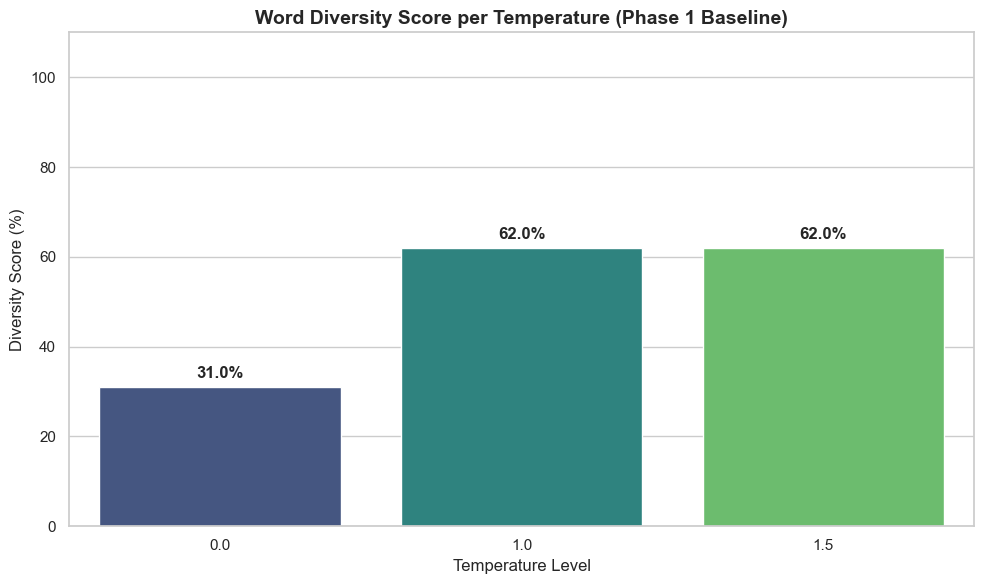

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

# Define the path to the Phase 1 file
BASELINE_PATH = "/Users/precioux/Desktop/Projects/Creativity/code/Server/Fractals/results/Gemini-3.1-Pro/dat_baseline_results.jsonl"

if Path(BASELINE_PATH).exists():
    df_base = pd.read_json(BASELINE_PATH, lines=True)
    
    # Calculate Diversity Score per Temperature
    temperatures = sorted(df_base['temperature'].unique())
    diversity_scores = []
    
    for temp in temperatures:
        temp_df = df_base[df_base['temperature'] == temp]
        
        all_words = []
        for parsed in temp_df['dat_parsed']:
            if isinstance(parsed, dict) and 'words' in parsed:
                # Clean and collect words
                words = [str(w).strip().lower() for w in parsed['words']]
                all_words.extend(words)
                
        total_words = len(all_words)
        unique_words = len(set(all_words))
        
        # Calculate percentage of unique words
        score = (unique_words / total_words * 100) if total_words > 0 else 0
        diversity_scores.append(score)

    # ==========================================
    # Plotting the Bar Chart
    # ==========================================
    sns.set_theme(style="whitegrid")
    plt.figure(figsize=(10, 6))
    
    # Draw the bar chart
    ax = sns.barplot(x=temperatures, y=diversity_scores, palette="viridis")
    
    # Labels and Titles
    plt.title('Word Diversity Score per Temperature (Phase 1 Baseline)', fontsize=14, fontweight='bold')
    plt.xlabel('Temperature Level', fontsize=12)
    plt.ylabel('Diversity Score (%)', fontsize=12)
    
    # Set Y-axis limit to 110 for better text visibility on top of bars
    plt.ylim(0, 110)
    
    # Add exact numeric values on top of each bar
    for i, score in enumerate(diversity_scores):
        ax.text(i, score + 2, f"{score:.1f}%", ha='center', fontsize=12, fontweight='bold')
        
    plt.tight_layout()
    plt.show()

else:
    print(f"ERROR: Could not find the file at {BASELINE_PATH}")

In [4]:
import pandas as pd
from pathlib import Path
from IPython.display import display

MAIN_PATH = "/Users/precioux/Desktop/Projects/Creativity/code/Server/Fractals/results/Gemini-3.1-Pro/main_results.jsonl"

print("Main Experiment (Phase 2) - Summary Table\n" + "="*50)

if Path(MAIN_PATH).exists():
    df_main = pd.read_json(MAIN_PATH, lines=True)
    
    def check_percepts(parsed_data):
        if isinstance(parsed_data, dict) and 'percepts' in parsed_data:
            return len(parsed_data['percepts']) > 0
        return False

    summary_data = []
    
    # Analyze data per temperature
    for temp in sorted(df_main['temperature'].unique()):
        temp_df = df_main[df_main['temperature'] == temp]
        total_runs = len(temp_df)
        
        # Count successes and failures
        success_mask = temp_df['fractal_parsed'].notnull() & temp_df['dat_parsed'].notnull()
        success_count = success_mask.sum()
        failed_count = total_runs - success_count
        
        # Analyze percepts only for successful runs
        successful_df = temp_df[success_mask].copy()
        successful_df['found_percept'] = successful_df['fractal_parsed'].apply(check_percepts)
        
        found_count = successful_df['found_percept'].sum()
        not_found_count = success_count - found_count
        
        # Calculate percentages based on successful runs
        found_pct = (found_count / success_count * 100) if success_count > 0 else 0
        not_found_pct = (not_found_count / success_count * 100) if success_count > 0 else 0
        
        summary_data.append({
            "Temperature": temp,
            "Total Tests": total_runs,
            "Successful Tests": success_count,
            "Failed (Errors)": failed_count,
            "Found Percepts (>0)": f"{found_count} ({found_pct:.1f}%)",
            "No Percepts (0)": f"{not_found_count} ({not_found_pct:.1f}%)"
        })
        
    df_summary = pd.DataFrame(summary_data)
    
    # Styling the table for readability in the notebook
    styled_df = df_summary.style.set_properties(**{'text-align': 'center'}).set_table_styles(
        [dict(selector='th', props=[('text-align', 'center'), ('font-weight', 'bold'), ('background-color', '#333333'), ('color', 'white')])]
    )
    
    display(styled_df)

else:
    print(f"ERROR: Could not find the file at {MAIN_PATH}")

Main Experiment (Phase 2) - Summary Table


,Temperature,Total Tests,Successful Tests,Failed (Errors),Found Percepts (>0),No Percepts (0)
0,0.000000,1553,1553,0,1553 (100.0%),0 (0.0%)
1,1.000000,1428,1424,4,1415 (99.4%),9 (0.6%)
2,1.500000,1544,1534,10,1527 (99.5%),7 (0.5%)


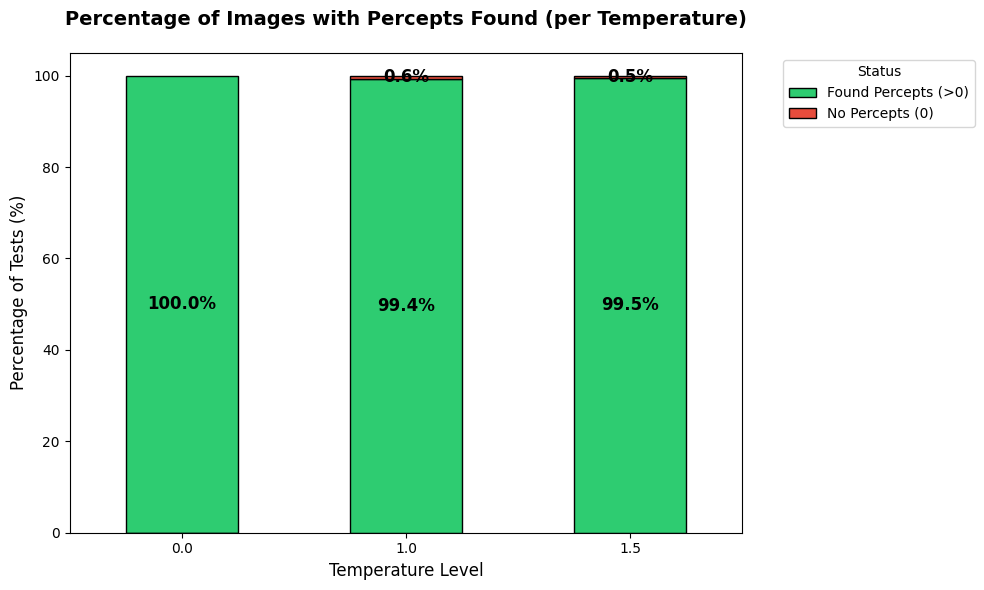

In [6]:
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

MAIN_PATH = "/Users/precioux/Desktop/Projects/Creativity/code/Server/Fractals/results/Gemini-3.1-Pro/main_results.jsonl"

if Path(MAIN_PATH).exists():
    df_main = pd.read_json(MAIN_PATH, lines=True)
    df_success = df_main[df_main['fractal_parsed'].notnull() & df_main['dat_parsed'].notnull()].copy()

    def check_percepts(parsed_data):
        if isinstance(parsed_data, dict) and 'percepts' in parsed_data:
            return len(parsed_data['percepts']) > 0
        return False

    df_success['found_percept'] = df_success['fractal_parsed'].apply(check_percepts)
    
    # Calculate percentages
    summary = df_success.groupby('temperature')['found_percept'].value_counts(normalize=True).unstack().fillna(0) * 100
    if True not in summary.columns: summary[True] = 0.0
    if False not in summary.columns: summary[False] = 0.0
    
    summary = summary.rename(columns={True: 'Found Percepts (>0)', False: 'No Percepts (0)'})
    summary = summary[['Found Percepts (>0)', 'No Percepts (0)']]
    # ---------------------

    # ==========================================
    # Plotting the Fixed Stacked Chart
    # ==========================================
    # Force a specific style so it doesn't break in Dark Mode
    plt.style.use('default') 
    
    fig, ax = plt.subplots(figsize=(10, 6))
    
    # Plot stacked bars
    summary.plot(kind='bar', stacked=True, color=['#2ecc71', '#e74c3c'], width=0.5, ax=ax, edgecolor='black')
    
    plt.title('Percentage of Images with Percepts Found (per Temperature)', fontsize=14, fontweight='bold', pad=20)
    plt.xlabel('Temperature Level', fontsize=12)
    plt.ylabel('Percentage of Tests (%)', fontsize=12)
    plt.xticks(rotation=0)
    
    # Move the legend completely outside the chart area
    plt.legend(title='Status', bbox_to_anchor=(1.05, 1), loc='upper left')

    # Add text labels inside the bars (only if the value is big enough to be visible)
    for p in ax.patches:
        width, height = p.get_width(), p.get_height()
        x, y = p.get_xy() 
        if height > 0.0:  # Avoid printing 0.0% to keep it clean
            # Position text in the center of the block
            ax.text(x + width/2, 
                    y + height/2, 
                    f'{height:.1f}%', 
                    ha='center', 
                    va='center', 
                    fontsize=12, 
                    fontweight='bold', 
                    color='black')

    plt.tight_layout()
    plt.show()

else:
    print(f"ERROR: Could not find the file at {MAIN_PATH}")

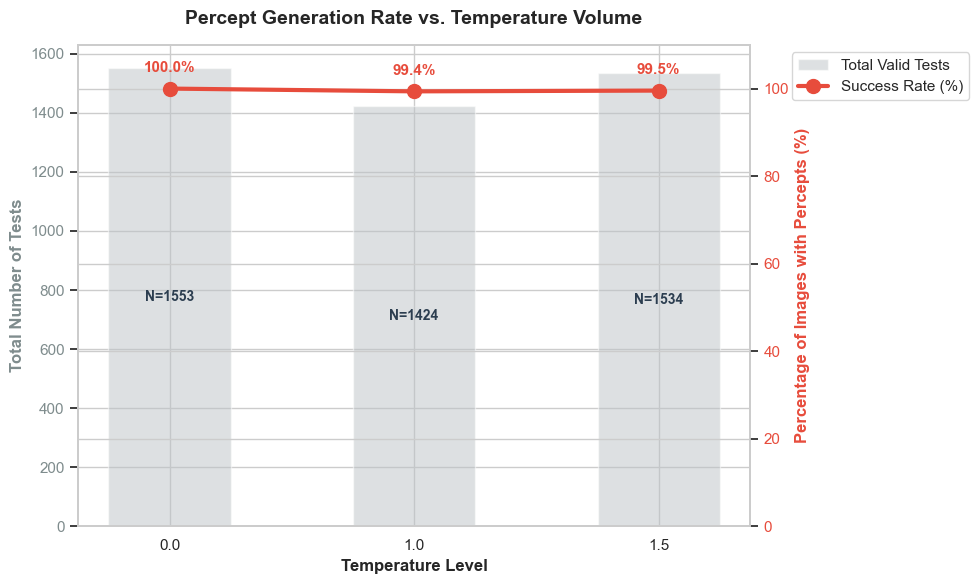

In [12]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import numpy as np

MAIN_PATH = "/Users/precioux/Desktop/Projects/Creativity/code/Server/Fractals/results/Gemini-3.1-Pro/main_results.jsonl"

if Path(MAIN_PATH).exists():
    df_main = pd.read_json(MAIN_PATH, lines=True)
    df_success = df_main[df_main['fractal_parsed'].notnull() & df_main['dat_parsed'].notnull()].copy()

    def check_percepts(parsed_data):
        if isinstance(parsed_data, dict) and 'percepts' in parsed_data:
            return len(parsed_data['percepts']) > 0
        return False

    df_success['found_percept'] = df_success['fractal_parsed'].apply(check_percepts)
    
    # Calculate both counts and percentages
    stats = df_success.groupby('temperature')['found_percept'].agg(
        Total_Tests='count',
        Success_Count='sum'
    )
    stats['Success_Rate'] = (stats['Success_Count'] / stats['Total_Tests']) * 100
    
    temperatures = stats.index.astype(str)
    
    # ==========================================
    # Plotting Dual-Axis Chart (Combo Plot)
    # ==========================================
    sns.set_theme(style="whitegrid")
    fig, ax1 = plt.subplots(figsize=(10, 6))
    
    # Axis 1: Background bars for Total Tests
    color_bar = '#bdc3c7'
    ax1.bar(temperatures, stats['Total_Tests'], color=color_bar, alpha=0.5, width=0.5, label='Total Valid Tests')
    ax1.set_xlabel('Temperature Level', fontsize=12, fontweight='bold')
    ax1.set_ylabel('Total Number of Tests', fontsize=12, color='#7f8c8d', fontweight='bold')
    ax1.tick_params(axis='y', labelcolor='#7f8c8d')
    
    # Add text for total counts inside background bars
    for i, v in enumerate(stats['Total_Tests']):
        ax1.text(i, v / 2, f"N={v}", ha='center', va='center', color='#2c3e50', fontsize=10, fontweight='bold')

    # Axis 2: Line plot for Success Rate (%)
    ax2 = ax1.twinx()  
    color_line = '#e74c3c'
    ax2.plot(temperatures, stats['Success_Rate'], color=color_line, marker='o', markersize=10, linewidth=3, label='Success Rate (%)')
    ax2.set_ylabel('Percentage of Images with Percepts (%)', fontsize=12, color=color_line, fontweight='bold')
    ax2.tick_params(axis='y', labelcolor=color_line)
    ax2.set_ylim(0, 110)
    
    # Add percentage labels on the line
    for i, v in enumerate(stats['Success_Rate']):
        ax2.text(i, v + 3, f"{v:.1f}%", ha='center', va='bottom', color=color_line, fontsize=11, fontweight='bold')

    plt.title('Percept Generation Rate vs. Temperature Volume', fontsize=14, fontweight='bold', pad=15)
    
    # Combine legends from both axes
    lines_1, labels_1 = ax1.get_legend_handles_labels()
    lines_2, labels_2 = ax2.get_legend_handles_labels()
    ax1.legend(lines_1 + lines_2, labels_1 + labels_2, loc='upper left', bbox_to_anchor=(1.05, 1))
    
    plt.tight_layout()
    plt.show()

else:
    print(f"ERROR: Could not find the file at {MAIN_PATH}")

In [15]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from IPython.display import display

# Define paths
METADATA_PATH = "/Users/precioux/Desktop/Projects/Creativity/FacesInThings/metadata.csv"
RESULTS_PATH = "/Users/precioux/Desktop/Projects/Creativity/code/Server/FaceInThings/results/FaceInThings/Gemini-3.1-Pro/main_results.jsonl"

# ==========================================
# IMPORTANT CONFIGURATION:
# 1. COMMON_COLUMN: The ID column that links both files (e.g., 'image_id', 'filename')
# 2. GROUPING_COLUMN: The metadata feature you want to evaluate by (e.g., 'category', 'difficulty', 'image_type')
# ==========================================
COMMON_COLUMN = "image_id"   
GROUPING_COLUMN = "category" 

def get_valid_words(parsed_data):
    """Extract exactly 10 valid words from parsed data."""
    if isinstance(parsed_data, dict) and 'words' in parsed_data:
        if isinstance(parsed_data['words'], list) and len(parsed_data['words']) == 10:
            return [str(w).strip().lower() for w in parsed_data['words']]
    return None

def check_percepts(parsed_data):
    """Check if the model found any percepts in the fractal image."""
    if isinstance(parsed_data, dict) and 'percepts' in parsed_data:
        return len(parsed_data['percepts']) > 0
    return False

def evaluate_quality_by_metadata():
    if not Path(METADATA_PATH).exists() or not Path(RESULTS_PATH).exists():
        print("ERROR: Could not find one of the data files.")
        return

    # 1. Load and Merge Data
    df_meta = pd.read_csv(METADATA_PATH)
    df_results = pd.read_json(RESULTS_PATH, lines=True)
    
    try:
        df = pd.merge(df_results, df_meta, on=COMMON_COLUMN, how='inner')
    except KeyError as e:
        print(f"ERROR: {e} column not found for merging. Check COMMON_COLUMN.")
        print(f"Available metadata columns: {df_meta.columns.tolist()}")
        return

    if GROUPING_COLUMN not in df.columns:
        print(f"ERROR: Column '{GROUPING_COLUMN}' not found in metadata.")
        print(f"Available columns: {df.columns.tolist()}")
        return

    # 2. Extract Features
    df['valid_words'] = df['dat_parsed'].apply(get_valid_words)
    df['found_percept'] = df['fractal_parsed'].apply(check_percepts)
    df['is_dat_valid'] = df['valid_words'].notnull()

    # 3. Calculate DAT Diversity per Metadata Group
    diversity_results = []
    for group_name, group_data in df[df['is_dat_valid']].groupby(GROUPING_COLUMN):
        all_words = []
        for words in group_data['valid_words']:
            all_words.extend(words)
            
        total_words = len(all_words)
        unique_words = len(set(all_words))
        diversity_score = (unique_words / total_words * 100) if total_words > 0 else 0
        
        diversity_results.append({
            GROUPING_COLUMN: group_name,
            "Valid DAT Runs": len(group_data),
            "Diversity Score (%)": round(diversity_score, 1)
        })
        
    df_diversity = pd.DataFrame(diversity_results)

    # 4. Calculate Fractal Percept Success Rate per Metadata Group
    percept_stats = df.groupby(GROUPING_COLUMN).agg(
        Total_Images=('found_percept', 'count'),
        Success_Count=('found_percept', 'sum')
    )
    percept_stats['Percept Success (%)'] = round((percept_stats['Success_Count'] / percept_stats['Total_Images']) * 100, 1)
    df_percept = percept_stats.reset_index()

    # 5. Merge and Display Final Report
    final_report = pd.merge(df_diversity, df_percept[[GROUPING_COLUMN, 'Total_Images', 'Percept Success (%)']], on=GROUPING_COLUMN, how='outer').fillna(0)
    
    print("\n" + "="*80)
    print(f"QUALITY EVALUATION BASED ON METADATA: '{GROUPING_COLUMN}'")
    print("="*80)
    styled_df = final_report.style.set_properties(**{'text-align': 'center'}).set_table_styles(
        [dict(selector='th', props=[('text-align', 'center'), ('font-weight', 'bold'), ('background-color', '#34495e'), ('color', 'white')])]
    )
    display(styled_df)

    # 6. Plotting the Results
    sns.set_theme(style="whitegrid")
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))

    # Chart 1: Diversity Score by Group
    sns.barplot(data=final_report, x=GROUPING_COLUMN, y='Diversity Score (%)', ax=axes[0], palette="mako")
    axes[0].set_title(f'Word Diversity by {GROUPING_COLUMN}', fontsize=14, fontweight='bold', pad=15)
    axes[0].set_ylim(0, 110)
    axes[0].tick_params(axis='x', rotation=45 if len(final_report) > 5 else 0)
    
    for p in axes[0].patches:
        axes[0].annotate(f"{p.get_height()}%", (p.get_x() + p.get_width() / 2., p.get_height()),
                         ha='center', va='bottom', xytext=(0, 5), textcoords='offset points', fontweight='bold')

    # Chart 2: Percept Success by Group
    sns.barplot(data=final_report, x=GROUPING_COLUMN, y='Percept Success (%)', ax=axes[1], palette="flare")
    axes[1].set_title(f'Percept Finding Success by {GROUPING_COLUMN}', fontsize=14, fontweight='bold', pad=15)
    axes[1].set_ylim(0, 110)
    axes[1].tick_params(axis='x', rotation=45 if len(final_report) > 5 else 0)
    
    for p in axes[1].patches:
        axes[1].annotate(f"{p.get_height()}%", (p.get_x() + p.get_width() / 2., p.get_height()),
                         ha='center', va='bottom', xytext=(0, 5), textcoords='offset points', fontweight='bold')

    plt.tight_layout()
    plt.show()

# Run the evaluation
evaluate_quality_by_metadata()

ERROR: 'image_id' column not found for merging. Check COMMON_COLUMN.
Available metadata columns: ['file', 'url', 'boxes', 'is_primary', 'Is there a face?', 'Hard to spot?', 'Accident or design?', 'Emotion?', 'Person or creature?', 'Gender?', 'Amusing?', 'Common?', 'Flags', 'num_boxes', 'train', 'split']


In [7]:
import pandas as pd
from pathlib import Path
from IPython.display import display

MAIN_PATH = "/Users/precioux/Desktop/Projects/Creativity/code/Server/Fractals/results/Gemini-3.1-Pro/main_results.jsonl"

print("Main Experiment (Phase 2) - Detailed Summary\n" + "="*65)

if Path(MAIN_PATH).exists():
    df_main = pd.read_json(MAIN_PATH, lines=True)
    
    def check_percepts(parsed_data):
        if isinstance(parsed_data, dict) and 'percepts' in parsed_data:
            return len(parsed_data['percepts']) > 0
        return False

    summary_data = []
    
    for temp in sorted(df_main['temperature'].unique()):
        temp_df = df_main[df_main['temperature'] == temp]
        total_runs = len(temp_df)
        
        # Checking if it's a valid JSON (Success) or Invalid (Failed)
        success_mask = temp_df['fractal_parsed'].notnull() & temp_df['dat_parsed'].notnull()
        valid_json_count = success_mask.sum()
        failed_count = total_runs - valid_json_count
        
        # Analyzing ONLY the successful valid JSONs
        successful_df = temp_df[success_mask].copy()
        successful_df['found_percept'] = successful_df['fractal_parsed'].apply(check_percepts)
        
        found_count = successful_df['found_percept'].sum()
        not_found_count = valid_json_count - found_count
        
        # Percentages
        found_pct = (found_count / valid_json_count * 100) if valid_json_count > 0 else 0
        not_found_pct = (not_found_count / valid_json_count * 100) if valid_json_count > 0 else 0
        
        summary_data.append({
            "Temperature": temp,
            "Total Requests": total_runs,
            "Failed (Invalid JSON)": failed_count,
            "Valid JSON (Total)": valid_json_count,
            "Success: Found Shapes": f"{found_count} ({found_pct:.1f}%)",
            "Success: Found ZERO Shapes": f"{not_found_count} ({not_found_pct:.1f}%)"
        })
        
    df_summary = pd.DataFrame(summary_data)
    
    # Styling
    styled_df = df_summary.style.set_properties(**{'text-align': 'center'}).set_table_styles(
        [dict(selector='th', props=[('text-align', 'center'), ('font-weight', 'bold'), ('background-color', '#2c3e50'), ('color', 'white')])]
    )
    
    display(styled_df)
    
    # Adding a clear explanation below the table
    print("\nTable Legend:")
    print("- Failed (Invalid JSON): The model returned corrupted JSON. These tests are discarded.")
    print("- Success: Found ZERO Shapes: The model successfully returned valid JSON, but found no shapes in the image.")

else:
    print(f"ERROR: Could not find the file at {MAIN_PATH}")

Main Experiment (Phase 2) - Detailed Summary


,Temperature,Total Requests,Failed (Invalid JSON),Valid JSON (Total),Success: Found Shapes,Success: Found ZERO Shapes
0,0.000000,1553,0,1553,1553 (100.0%),0 (0.0%)
1,1.000000,1428,4,1424,1415 (99.4%),9 (0.6%)
2,1.500000,1544,10,1534,1527 (99.5%),7 (0.5%)



Table Legend:
- Failed (Invalid JSON): The model returned corrupted JSON. These tests are discarded.
- Success: Found ZERO Shapes: The model successfully returned valid JSON, but found no shapes in the image.


Phase 2 (Primed DAT) - Word Diversity Analysis


,Temperature,Valid Runs,Total Words,Unique Words,Diversity Score (%)
0,0.000000,1553,15530,351,2.3%
1,1.000000,1428,14280,614,4.3%
2,1.500000,1544,15440,666,4.3%


/var/folders/_m/qyd_78r54hlc3qlgxy6q01qm0000gn/T/ipykernel_12178/1947407591.py:70: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x=temperatures, y=diversity_scores, palette="flare")


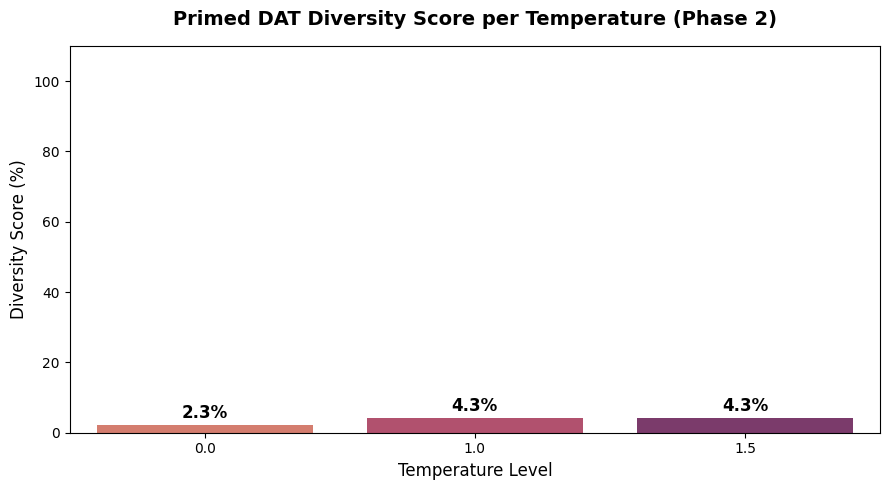

In [8]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from IPython.display import display

# Change this path to evaluate other models (Gemma3-26b, Claude-Opus-4-7, GPT-5.4)
MAIN_PATH = "/Users/precioux/Desktop/Projects/Creativity/code/Server/Fractals/results/Gemini-3.1-Pro/main_results.jsonl"

print("Phase 2 (Primed DAT) - Word Diversity Analysis\n" + "="*60)

if Path(MAIN_PATH).exists():
    df_main = pd.read_json(MAIN_PATH, lines=True)
    
    # Filter and extract exactly 10 words for valid DAT runs in Phase 2
    def get_valid_words(parsed_data):
        if isinstance(parsed_data, dict) and 'words' in parsed_data:
            if isinstance(parsed_data['words'], list) and len(parsed_data['words']) == 10:
                # Clean, lowercase, and strip spaces from words
                return [str(w).strip().lower() for w in parsed_data['words']]
        return None

    df_main['valid_words'] = df_main['dat_parsed'].apply(get_valid_words)
    
    # Keep only the rows where DAT parsing was successful
    df_success = df_main[df_main['valid_words'].notnull()].copy()
    
    analysis_results = []
    temperatures = sorted(df_success['temperature'].unique())
    diversity_scores = []
    
    for temp in temperatures:
        temp_df = df_success[df_success['temperature'] == temp]
        total_valid_runs = len(temp_df)
        
        all_words = []
        for word_list in temp_df['valid_words']:
            all_words.extend(word_list)
            
        total_words = len(all_words)
        unique_words = len(set(all_words))
        
        # Calculate Diversity Score for Phase 2
        diversity_score = (unique_words / total_words * 100) if total_words > 0 else 0
        diversity_scores.append(diversity_score)
        
        analysis_results.append({
            "Temperature": temp,
            "Valid Runs": total_valid_runs,
            "Total Words": total_words,
            "Unique Words": unique_words,
            "Diversity Score (%)": f"{diversity_score:.1f}%"
        })

    # ==========================================
    # Display the Summary Table
    # ==========================================
    df_analysis = pd.DataFrame(analysis_results)
    styled_df = df_analysis.style.set_properties(**{'text-align': 'center'}).set_table_styles(
        [dict(selector='th', props=[('text-align', 'center'), ('font-weight', 'bold'), ('background-color', '#d35400'), ('color', 'white')])]
    )
    display(styled_df)
    
    # ==========================================
    # Plotting the Bar Chart
    # ==========================================
    plt.style.use('default')
    plt.figure(figsize=(9, 5))
    
    ax = sns.barplot(x=temperatures, y=diversity_scores, palette="flare")
    
    plt.title('Primed DAT Diversity Score per Temperature (Phase 2)', fontsize=14, fontweight='bold', pad=15)
    plt.xlabel('Temperature Level', fontsize=12)
    plt.ylabel('Diversity Score (%)', fontsize=12)
    plt.ylim(0, 110)
    
    for i, score in enumerate(diversity_scores):
        ax.text(i, score + 2, f"{score:.1f}%", ha='center', fontsize=12, fontweight='bold')
        
    plt.tight_layout()
    plt.show()

else:
    print(f"ERROR: Could not find the file at {MAIN_PATH}")


Comparison: Phase 1 (Baseline) vs Phase 2 (Primed)


,Temperature,Valid Runs (Phase 1),Total Words (Phase 1),Diversity % (Phase 1),Valid Runs (Phase 2),Total Words (Phase 2),Diversity % (Phase 2)
0,0.000000,10,100,31.000000,1553,15530,2.300000
1,1.000000,10,100,62.000000,1428,14280,4.300000
2,1.500000,10,100,62.000000,1544,15440,4.300000


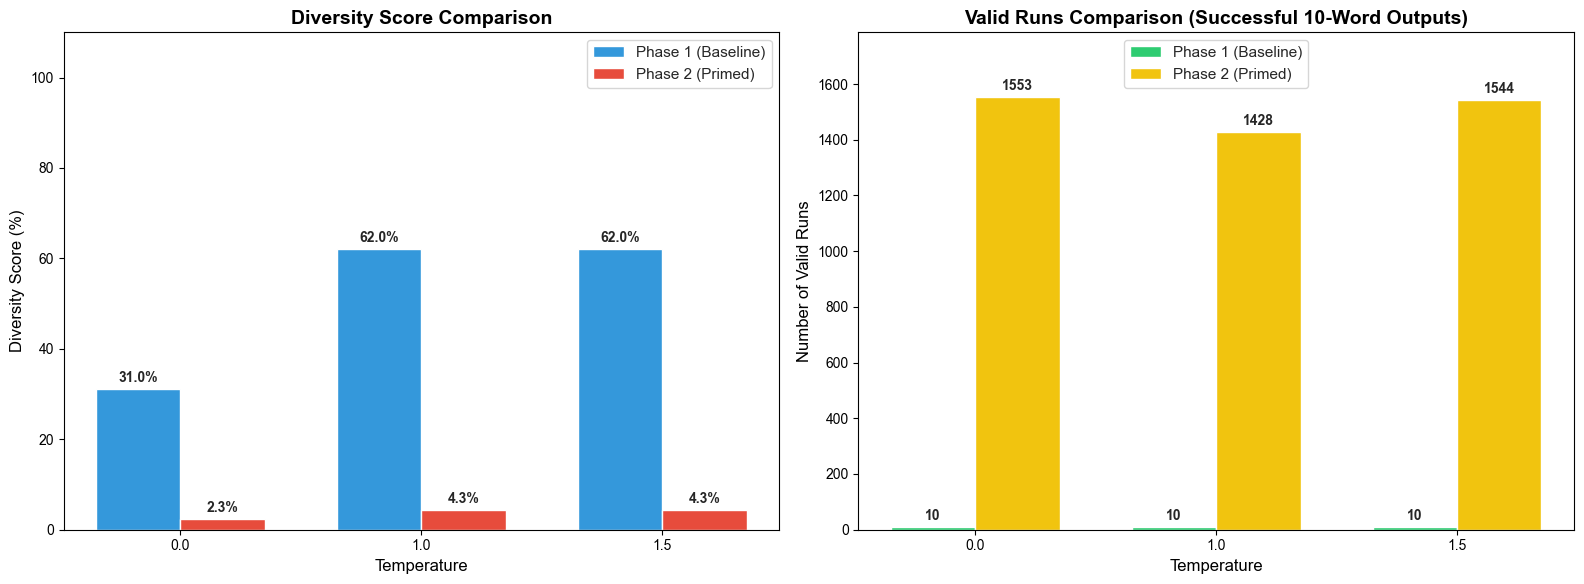

In [9]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from IPython.display import display
import numpy as np

# Define file paths
BASELINE_PATH = "/Users/precioux/Desktop/Projects/Creativity/code/Server/Fractals/results/Gemini-3.1-Pro/dat_baseline_results.jsonl"
MAIN_PATH = "/Users/precioux/Desktop/Projects/Creativity/code/Server/Fractals/results/Gemini-3.1-Pro/main_results.jsonl"

def get_valid_words(parsed_data):
    """Extract exactly 10 valid words from parsed data."""
    if isinstance(parsed_data, dict) and 'words' in parsed_data:
        if isinstance(parsed_data['words'], list) and len(parsed_data['words']) == 10:
            return [str(w).strip().lower() for w in parsed_data['words']]
    return None

def process_data(file_path, phase_name):
    """Read and process data for a specific phase."""
    if not Path(file_path).exists():
        print(f"ERROR: File not found at {file_path}")
        return pd.DataFrame()
        
    df = pd.read_json(file_path, lines=True)
    df['valid_words'] = df['dat_parsed'].apply(get_valid_words)
    df_success = df[df['valid_words'].notnull()].copy()
    
    results = []
    temperatures = sorted(df_success['temperature'].unique())
    
    for temp in temperatures:
        temp_df = df_success[df_success['temperature'] == temp]
        valid_runs = len(temp_df)
        
        all_words = []
        for word_list in temp_df['valid_words']:
            all_words.extend(word_list)
            
        total_words = len(all_words)
        unique_words = len(set(all_words))
        diversity_score = (unique_words / total_words * 100) if total_words > 0 else 0
        
        results.append({
            "Temperature": temp,
            f"Valid Runs ({phase_name})": valid_runs,
            f"Total Words ({phase_name})": total_words,
            f"Diversity % ({phase_name})": round(diversity_score, 1)
        })
        
    return pd.DataFrame(results)

# 1. Process both files
df_phase1 = process_data(BASELINE_PATH, "Phase 1")
df_phase2 = process_data(MAIN_PATH, "Phase 2")

if not df_phase1.empty and not df_phase2.empty:
    # 2. Merge data based on Temperature
    df_combined = pd.merge(df_phase1, df_phase2, on="Temperature", how="outer").fillna(0)
    
    # 3. Display the comparison table
    print("\n" + "="*80)
    print("Comparison: Phase 1 (Baseline) vs Phase 2 (Primed)")
    print("="*80)
    
    styled_df = df_combined.style.set_properties(**{'text-align': 'center'}).set_table_styles(
        [dict(selector='th', props=[('text-align', 'center'), ('font-weight', 'bold'), ('background-color', '#2c3e50'), ('color', 'white')])]
    )
    display(styled_df)

    # 4. Plot the comparison charts
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))
    sns.set_theme(style="whitegrid")
    
    x = np.arange(len(df_combined['Temperature']))
    width = 0.35  # Bar width
    
    # --- Chart 1: Diversity Score Comparison ---
    rects1 = ax1.bar(x - width/2, df_combined['Diversity % (Phase 1)'], width, label='Phase 1 (Baseline)', color='#3498db')
    rects2 = ax1.bar(x + width/2, df_combined['Diversity % (Phase 2)'], width, label='Phase 2 (Primed)', color='#e74c3c')
    
    ax1.set_title('Diversity Score Comparison', fontsize=14, fontweight='bold')
    ax1.set_xlabel('Temperature', fontsize=12)
    ax1.set_ylabel('Diversity Score (%)', fontsize=12)
    ax1.set_xticks(x)
    ax1.set_xticklabels(df_combined['Temperature'])
    ax1.set_ylim(0, 110)
    ax1.legend()
    
    # Add percentage labels on top of bars
    for rects in [rects1, rects2]:
        for rect in rects:
            height = rect.get_height()
            if height > 0:
                ax1.annotate(f'{height}%',
                            xy=(rect.get_x() + rect.get_width() / 2, height),
                            xytext=(0, 3),
                            textcoords="offset points",
                            ha='center', va='bottom', fontsize=10, fontweight='bold')

    # --- Chart 2: Valid Runs Comparison ---
    rects3 = ax2.bar(x - width/2, df_combined['Valid Runs (Phase 1)'], width, label='Phase 1 (Baseline)', color='#2ecc71')
    rects4 = ax2.bar(x + width/2, df_combined['Valid Runs (Phase 2)'], width, label='Phase 2 (Primed)', color='#f1c40f')
    
    ax2.set_title('Valid Runs Comparison (Successful 10-Word Outputs)', fontsize=14, fontweight='bold')
    ax2.set_xlabel('Temperature', fontsize=12)
    ax2.set_ylabel('Number of Valid Runs', fontsize=12)
    ax2.set_xticks(x)
    ax2.set_xticklabels(df_combined['Temperature'])
    
    # Find maximum value to set Y-axis height
    max_runs = max(df_combined['Valid Runs (Phase 1)'].max(), df_combined['Valid Runs (Phase 2)'].max())
    ax2.set_ylim(0, max_runs * 1.15)
    ax2.legend()
    
    # Add exact numeric values on top of bars
    for rects in [rects3, rects4]:
        for rect in rects:
            height = rect.get_height()
            if height > 0:
                ax2.annotate(f'{int(height)}',
                            xy=(rect.get_x() + rect.get_width() / 2, height),
                            xytext=(0, 3),
                            textcoords="offset points",
                            ha='center', va='bottom', fontsize=10, fontweight='bold')

    plt.tight_layout()
    plt.show()

Loading SpaCy NLP model (this might take a few seconds)...
Extracting words from files...
Converting words to vectors...

SEMANTIC DISTANCE ANALYSIS (Cosine Distance)
Internal Distance - Phase 1 (Baseline): 0.8442
Internal Distance - Phase 2 (Primed):   0.8626
Distance BETWEEN Phase 1 & Phase 2:     0.8581
*(Higher internal distance = more creative/divergent words)*

Applying PCA to reduce dimensions to 2D for plotting...


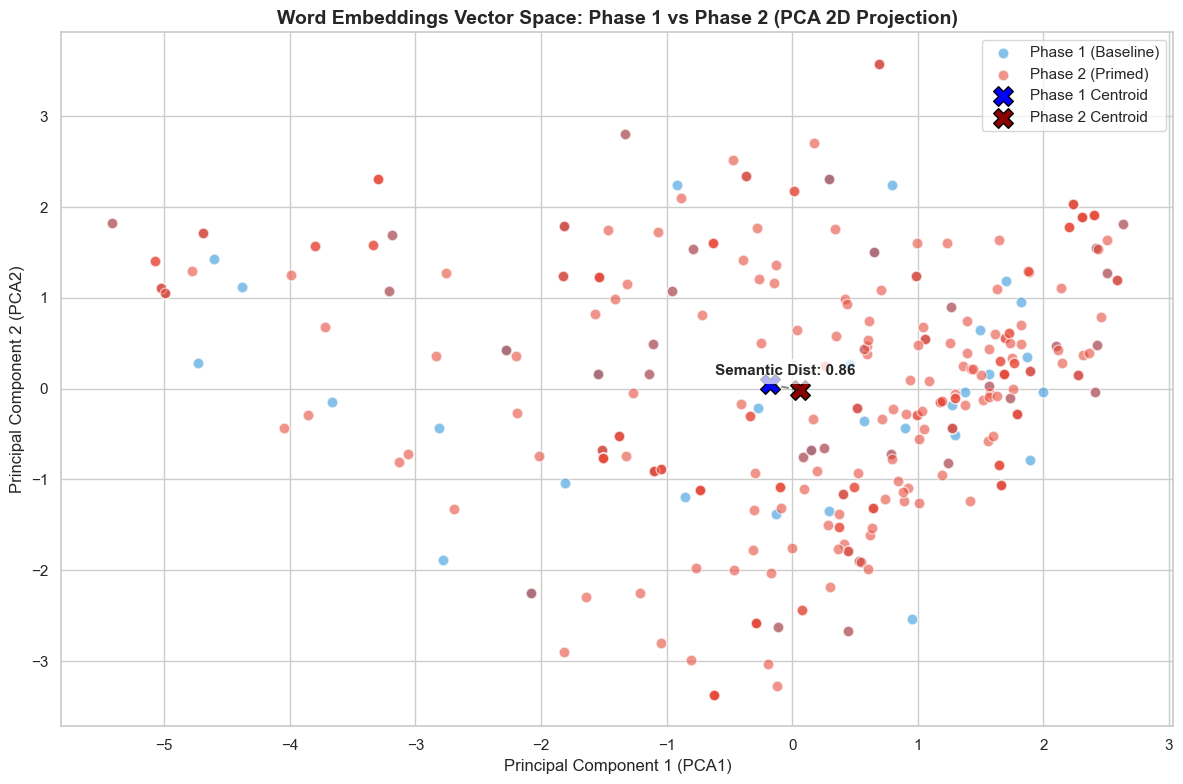

In [11]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from pathlib import Path
import spacy
from sklearn.decomposition import PCA
from sklearn.metrics.pairwise import cosine_distances

# 1. Load the NLP model (Medium size English model with 300D word vectors)
print("Loading SpaCy NLP model (this might take a few seconds)...")
try:
    nlp = spacy.load("en_core_web_md")
except OSError:
    print("ERROR: Model 'en_core_web_md' not found.")
    print("Please run: python -m spacy download en_core_web_md")
    exit()

# Define file paths
BASELINE_PATH = "/Users/precioux/Desktop/Projects/Creativity/code/Server/Fractals/results/Gemini-3.1-Pro/dat_baseline_results.jsonl"
MAIN_PATH = "/Users/precioux/Desktop/Projects/Creativity/code/Server/Fractals/results/Gemini-3.1-Pro/main_results.jsonl"

def get_valid_words(parsed_data):
    """Extract exactly 10 valid words from parsed data."""
    if isinstance(parsed_data, dict) and 'words' in parsed_data:
        if isinstance(parsed_data['words'], list) and len(parsed_data['words']) == 10:
            return [str(w).strip().lower() for w in parsed_data['words']]
    return []

def get_unique_words_from_file(file_path):
    """Extract all unique valid words from a given JSONL file."""
    if not Path(file_path).exists():
        print(f"ERROR: File not found at {file_path}")
        return set()
        
    df = pd.read_json(file_path, lines=True)
    df['valid_words'] = df['dat_parsed'].apply(get_valid_words)
    
    all_words = set()
    for word_list in df['valid_words'].dropna():
        all_words.update(word_list)
        
    return list(all_words)

# 2. Extract unique words from both phases
print("Extracting words from files...")
phase1_words = get_unique_words_from_file(BASELINE_PATH)
phase2_words = get_unique_words_from_file(MAIN_PATH)

# To keep the plot readable and processing fast, we sample up to 300 words from each phase
SAMPLE_SIZE = 300
if len(phase1_words) > SAMPLE_SIZE:
    phase1_words = np.random.choice(phase1_words, SAMPLE_SIZE, replace=False).tolist()
if len(phase2_words) > SAMPLE_SIZE:
    phase2_words = np.random.choice(phase2_words, SAMPLE_SIZE, replace=False).tolist()

def get_vectors_and_clean_words(words_list):
    """Convert words to vectors and filter out Out-Of-Vocabulary (OOV) words."""
    vectors = []
    clean_words = []
    for w in words_list:
        token = nlp(w)
        if token.has_vector and token.vector_norm != 0:
            vectors.append(token.vector)
            clean_words.append(w)
    return np.array(vectors), clean_words

# 3. Convert words to 300-Dimensional vectors
print("Converting words to vectors...")
vec1, words1 = get_vectors_and_clean_words(phase1_words)
vec2, words2 = get_vectors_and_clean_words(phase2_words)

if len(vec1) == 0 or len(vec2) == 0:
    print("ERROR: Not enough valid vectors found to compute distances.")
else:
    # 4. Calculate Average Semantic Distances
    # Calculate average distance between Phase 1 and Phase 2 clusters
    cross_phase_distance = np.mean(cosine_distances(vec1, vec2))
    
    # Calculate internal diversity (average distance within each group)
    internal_dist1 = np.mean(cosine_distances(vec1, vec1))
    internal_dist2 = np.mean(cosine_distances(vec2, vec2))
    
    print("\n" + "="*50)
    print("SEMANTIC DISTANCE ANALYSIS (Cosine Distance)")
    print("="*50)
    print(f"Internal Distance - Phase 1 (Baseline): {internal_dist1:.4f}")
    print(f"Internal Distance - Phase 2 (Primed):   {internal_dist2:.4f}")
    print(f"Distance BETWEEN Phase 1 & Phase 2:     {cross_phase_distance:.4f}")
    print("*(Higher internal distance = more creative/divergent words)*")
    print("="*50 + "\n")

    # 5. Dimensionality Reduction (300D -> 2D) using PCA for visualization
    print("Applying PCA to reduce dimensions to 2D for plotting...")
    all_vectors = np.vstack((vec1, vec2))
    pca = PCA(n_components=2)
    all_vectors_2d = pca.fit_transform(all_vectors)
    
    # Split back into phase 1 and phase 2
    vec1_2d = all_vectors_2d[:len(vec1)]
    vec2_2d = all_vectors_2d[len(vec1):]

    # 6. Plotting the Vector Space
    plt.figure(figsize=(12, 8))
    sns.set_theme(style="whitegrid")
    
    # Plot Phase 1
    plt.scatter(vec1_2d[:, 0], vec1_2d[:, 1], alpha=0.6, c='#3498db', edgecolors='w', s=60, label='Phase 1 (Baseline)')
    
    # Plot Phase 2
    plt.scatter(vec2_2d[:, 0], vec2_2d[:, 1], alpha=0.6, c='#e74c3c', edgecolors='w', s=60, label='Phase 2 (Primed)')
    
    # Plot Centroids (Center of mass for each cluster)
    centroid1 = np.mean(vec1_2d, axis=0)
    centroid2 = np.mean(vec2_2d, axis=0)
    
    plt.scatter(*centroid1, c='blue', s=200, marker='X', edgecolor='black', label='Phase 1 Centroid')
    plt.scatter(*centroid2, c='darkred', s=200, marker='X', edgecolor='black', label='Phase 2 Centroid')
    
    # Draw a line connecting the two centroids
    plt.plot([centroid1[0], centroid2[0]], [centroid1[1], centroid2[1]], 'k--', alpha=0.5)
    
    # Add distance text in the middle of the line
    mid_point = (centroid1 + centroid2) / 2
    plt.text(mid_point[0], mid_point[1] + 0.1, f"Semantic Dist: {cross_phase_distance:.2f}", 
             ha='center', va='bottom', fontsize=11, fontweight='bold', bbox=dict(facecolor='white', alpha=0.7, edgecolor='none'))

    plt.title('Word Embeddings Vector Space: Phase 1 vs Phase 2 (PCA 2D Projection)', fontsize=14, fontweight='bold')
    plt.xlabel('Principal Component 1 (PCA1)', fontsize=12)
    plt.ylabel('Principal Component 2 (PCA2)', fontsize=12)
    plt.legend(loc='best')
    plt.tight_layout()
    plt.show()

## Gemma

In [10]:
import pandas as pd
import numpy as np
from itertools import combinations
from pathlib import Path
from IPython.display import display
import spacy
from spacy.cli import download

# ==========================================
# 1. Setup and Model Loading
# ==========================================
MODEL_NAME = "en_core_web_md"

try:
    nlp = spacy.load(MODEL_NAME)
    print(f"Successfully loaded '{MODEL_NAME}'.")
except OSError:
    print(f"Model '{MODEL_NAME}' not found. Downloading it automatically now...")
    download(MODEL_NAME)
    # Load again after downloading
    nlp = spacy.load(MODEL_NAME)
    print("Download complete and model loaded!")

# ==========================================
# 2. Configuration & Logic
# ==========================================
# Change this path to evaluate other models (Gemma3-26b, Claude-Opus-4-7, GPT-5.4)
DATA_PATH = "/Users/precioux/Desktop/Projects/Creativity/code/Server/Fractals/results/Gemini-3.1-Pro/main_results.jsonl"

def calculate_semantic_variance(word_list):
    """
    Calculates the average cosine distance (semantic variance) 
    between all unique pairs of words in the given list.
    A higher score means the words are more semantically diverse (higher variance).
    """
    if not isinstance(word_list, list) or len(word_list) < 2:
        return np.nan
        
    # Get vectors for valid words
    tokens = [nlp(str(w).strip().lower()) for w in word_list]
    valid_tokens = [t for t in tokens if t.has_vector]
    
    if len(valid_tokens) < 2:
        return np.nan
        
    distances = []
    # Calculate cosine distance for every possible pair in the 10 words
    for t1, t2 in combinations(valid_tokens, 2):
        # Similarity is between 0.0 and 1.0. Distance is 1.0 - similarity.
        sim = t1.similarity(t2)
        distances.append(1.0 - sim)
        
    return np.mean(distances)

# ==========================================
# 3. Execution and Table Generation
# ==========================================
print("\nAnalyzing True Semantic Variance (Cosine Distance) via SpaCy\n" + "="*60)

if Path(DATA_PATH).exists():
    df = pd.read_json(DATA_PATH, lines=True)
    
    # Extract valid 10-word lists
    def extract_words(parsed_data):
        if isinstance(parsed_data, dict) and 'words' in parsed_data:
            words = parsed_data['words']
            if isinstance(words, list) and len(words) == 10:
                return words
        return None

    df['valid_words'] = df['dat_parsed'].apply(extract_words)
    df_valid = df[df['valid_words'].notnull()].copy()
    
    # Calculate the variance for each run
    df_valid['semantic_variance'] = df_valid['valid_words'].apply(calculate_semantic_variance)
    
    # Aggregate results by temperature
    summary = df_valid.groupby('temperature')['semantic_variance'].agg(['mean', 'std', 'count']).reset_index()
    summary = summary.rename(columns={
        'temperature': 'Temperature Level', 
        'mean': 'Mean Semantic Distance (Variance)',
        'std': 'Standard Deviation',
        'count': 'Valid Runs Evaluated'
    })
    
    # Display the styled table
    styled_summary = summary.style.set_properties(**{'text-align': 'center'}).set_table_styles(
        [dict(selector='th', props=[('text-align', 'center'), ('font-weight', 'bold'), ('background-color', '#8e44ad'), ('color', 'white')])]
    ).format({
        'Mean Semantic Distance (Variance)': '{:.4f}',
        'Standard Deviation': '{:.4f}'
    })
    
    display(styled_summary)

else:
    print(f"ERROR: Could not find the file at {DATA_PATH}")

Successfully loaded 'en_core_web_md'.

Analyzing True Semantic Variance (Cosine Distance) via SpaCy


,Temperature Level,Mean Semantic Distance (Variance),Standard Deviation,Valid Runs Evaluated
0,0.000000,0.8411,0.0256,1553
1,1.000000,0.8573,0.0255,1428
2,1.500000,0.8563,0.0266,1544


## Gemma

Gemma Model: Analyzing DAT Baseline (Phase 1)


,Temperature,Success Rate,Total Words,Unique Words,Diversity Score (%)
0,0.000000,10 / 10,100,10,10.0%
1,1.000000,10 / 10,100,37,37.0%
2,1.500000,10 / 10,100,47,47.0%


/var/folders/_m/qyd_78r54hlc3qlgxy6q01qm0000gn/T/ipykernel_31099/1584618221.py:60: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x=temperatures, y=diversity_scores, palette="mako")


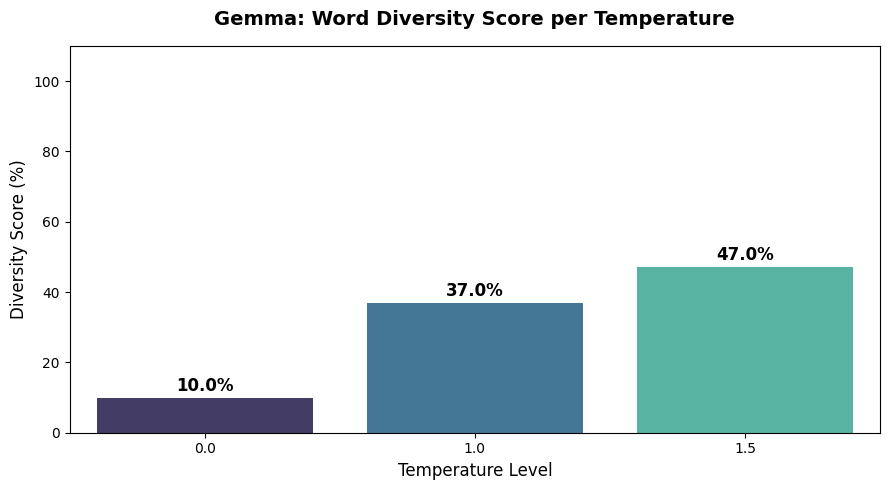

In [19]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from IPython.display import display

# Path adjusted for the Gemma output directory
BASELINE_PATH = "/Users/precioux/Desktop/Projects/Creativity/code/Server/Fractals/results/Gemma3-26b/dat_baseline_results.jsonl"

print("Gemma Model: Analyzing DAT Baseline (Phase 1)\n" + "="*60)

if Path(BASELINE_PATH).exists():
    df_base = pd.read_json(BASELINE_PATH, lines=True)
    
    def check_success(parsed_data):
        if isinstance(parsed_data, dict) and 'words' in parsed_data:
            if isinstance(parsed_data['words'], list) and len(parsed_data['words']) == 10:
                return True
        return False

    df_base['is_successful'] = df_base['dat_parsed'].apply(check_success)
    
    analysis_results = []
    temperatures = sorted(df_base['temperature'].unique())
    diversity_scores = []
    
    for temp in temperatures:
        temp_df = df_base[(df_base['temperature'] == temp) & (df_base['is_successful'] == True)]
        total_runs = len(df_base[df_base['temperature'] == temp])
        success_runs = len(temp_df)
        
        all_words = []
        for words_list in temp_df['dat_parsed'].apply(lambda x: x['words']):
            cleaned = [str(w).strip().lower() for w in words_list]
            all_words.extend(cleaned)
            
        total_words = len(all_words)
        unique_words = len(set(all_words))
        diversity_score = (unique_words / total_words * 100) if total_words > 0 else 0
        diversity_scores.append(diversity_score)
        
        analysis_results.append({
            "Temperature": temp,
            "Success Rate": f"{success_runs} / {total_runs}",
            "Total Words": total_words,
            "Unique Words": unique_words,
            "Diversity Score (%)": f"{diversity_score:.1f}%"
        })

    # Display Table
    df_analysis = pd.DataFrame(analysis_results)
    styled_df = df_analysis.style.set_properties(**{'text-align': 'center'}).set_table_styles(
        [dict(selector='th', props=[('text-align', 'center'), ('font-weight', 'bold'), ('background-color', '#1e3799'), ('color', 'white')])]
    )
    display(styled_df)
    
    # Draw Bar Chart
    plt.style.use('default')
    plt.figure(figsize=(9, 5))
    ax = sns.barplot(x=temperatures, y=diversity_scores, palette="mako")
    plt.title('Gemma: Word Diversity Score per Temperature', fontsize=14, fontweight='bold', pad=15)
    plt.xlabel('Temperature Level', fontsize=12)
    plt.ylabel('Diversity Score (%)', fontsize=12)
    plt.ylim(0, 110)
    
    for i, score in enumerate(diversity_scores):
        ax.text(i, score + 2, f"{score:.1f}%", ha='center', fontsize=12, fontweight='bold')
        
    plt.tight_layout()
    plt.show()

else:
    print(f"ERROR: Could not find the file at {BASELINE_PATH}")

Gemma Model: Main Experiment Analysis (Phase 2)


,Temperature,Total Requests,Failed (Invalid JSON),Valid JSON (Total),Success: Found Shapes,Success: Found ZERO Shapes
0,0.000000,1610,0,1610,263 (16.3%),1347 (83.7%)
1,1.000000,1610,0,1610,359 (22.3%),1251 (77.7%)
2,1.500000,1610,3,1607,517 (32.2%),1090 (67.8%)



Table Legend:
- Failed (Invalid JSON): The model returned corrupted JSON. These tests are discarded.
- Success: Found ZERO Shapes: Valid JSON, but found no shapes in the image.



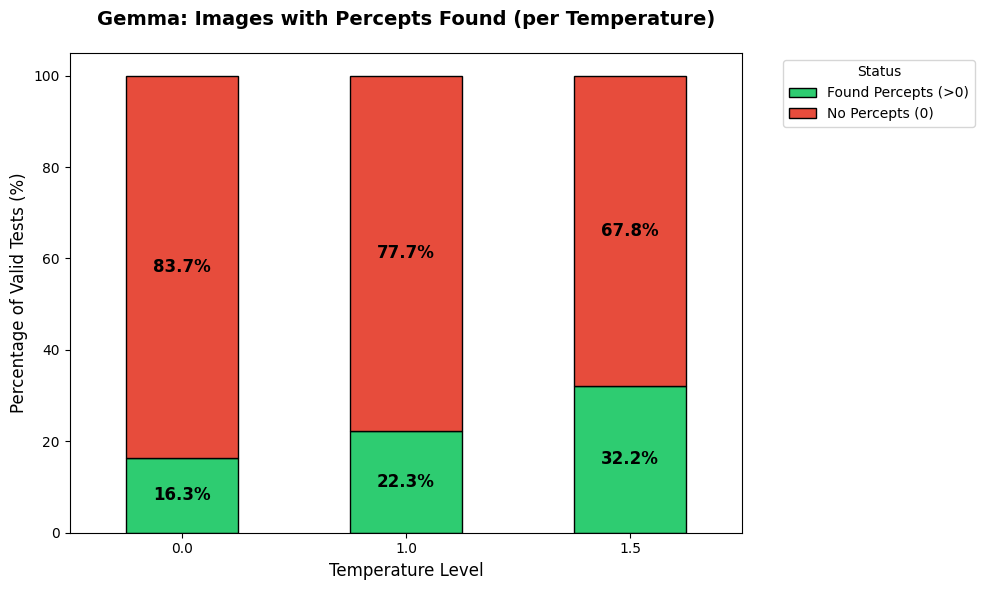

In [20]:
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from IPython.display import display

# Path adjusted for the Gemma output directory
MAIN_PATH = "/Users/precioux/Desktop/Projects/Creativity/code/Server/Fractals/results/Gemma3-26b/main_results.jsonl"

print("Gemma Model: Main Experiment Analysis (Phase 2)\n" + "="*60)

if Path(MAIN_PATH).exists():
    df_main = pd.read_json(MAIN_PATH, lines=True)
    
    def check_percepts(parsed_data):
        if isinstance(parsed_data, dict) and 'percepts' in parsed_data:
            return len(parsed_data['percepts']) > 0
        return False

    summary_data = []
    
    # 1. Generate Summary Table
    for temp in sorted(df_main['temperature'].unique()):
        temp_df = df_main[df_main['temperature'] == temp]
        total_runs = len(temp_df)
        
        success_mask = temp_df['fractal_parsed'].notnull() & temp_df['dat_parsed'].notnull()
        valid_json_count = success_mask.sum()
        failed_count = total_runs - valid_json_count
        
        successful_df = temp_df[success_mask].copy()
        successful_df['found_percept'] = successful_df['fractal_parsed'].apply(check_percepts)
        
        found_count = successful_df['found_percept'].sum()
        not_found_count = valid_json_count - found_count
        
        found_pct = (found_count / valid_json_count * 100) if valid_json_count > 0 else 0
        not_found_pct = (not_found_count / valid_json_count * 100) if valid_json_count > 0 else 0
        
        summary_data.append({
            "Temperature": temp,
            "Total Requests": total_runs,
            "Failed (Invalid JSON)": failed_count,
            "Valid JSON (Total)": valid_json_count,
            "Success: Found Shapes": f"{found_count} ({found_pct:.1f}%)",
            "Success: Found ZERO Shapes": f"{not_found_count} ({not_found_pct:.1f}%)"
        })
        
    df_summary = pd.DataFrame(summary_data)
    styled_df = df_summary.style.set_properties(**{'text-align': 'center'}).set_table_styles(
        [dict(selector='th', props=[('text-align', 'center'), ('font-weight', 'bold'), ('background-color', '#2c3e50'), ('color', 'white')])]
    )
    display(styled_df)
    
    print("\nTable Legend:")
    print("- Failed (Invalid JSON): The model returned corrupted JSON. These tests are discarded.")
    print("- Success: Found ZERO Shapes: Valid JSON, but found no shapes in the image.\n")

    # 2. Prepare Data for Stacked Bar Chart
    df_success = df_main[df_main['fractal_parsed'].notnull() & df_main['dat_parsed'].notnull()].copy()
    df_success['found_percept'] = df_success['fractal_parsed'].apply(check_percepts)
    
    summary_chart = df_success.groupby('temperature')['found_percept'].value_counts(normalize=True).unstack().fillna(0) * 100
    if True not in summary_chart.columns: summary_chart[True] = 0.0
    if False not in summary_chart.columns: summary_chart[False] = 0.0
    
    summary_chart = summary_chart.rename(columns={True: 'Found Percepts (>0)', False: 'No Percepts (0)'})
    summary_chart = summary_chart[['Found Percepts (>0)', 'No Percepts (0)']]

    # 3. Draw Stacked Bar Chart
    plt.style.use('default') 
    fig, ax = plt.subplots(figsize=(10, 6))
    
    summary_chart.plot(kind='bar', stacked=True, color=['#2ecc71', '#e74c3c'], width=0.5, ax=ax, edgecolor='black')
    
    plt.title('Gemma: Images with Percepts Found (per Temperature)', fontsize=14, fontweight='bold', pad=20)
    plt.xlabel('Temperature Level', fontsize=12)
    plt.ylabel('Percentage of Valid Tests (%)', fontsize=12)
    plt.xticks(rotation=0)
    plt.legend(title='Status', bbox_to_anchor=(1.05, 1), loc='upper left')

    for p in ax.patches:
        width, height = p.get_width(), p.get_height()
        x, y = p.get_xy() 
        if height > 0.0:
            ax.text(x + width/2, y + height/2, f'{height:.1f}%', ha='center', va='center', fontsize=12, fontweight='bold', color='black')

    plt.tight_layout()
    plt.show()

else:
    print(f"ERROR: Could not find the file at {MAIN_PATH}")

Gemma Model: Phase 2 (Primed DAT) - Word Diversity Analysis


,Temperature,Valid Runs,Total Words,Unique Words,Diversity Score (%)
0,0.000000,1610,16100,49,0.3%
1,1.000000,1610,16100,185,1.1%
2,1.500000,1606,16060,326,2.0%


/var/folders/_m/qyd_78r54hlc3qlgxy6q01qm0000gn/T/ipykernel_31099/3027311960.py:67: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x=temperatures, y=diversity_scores, palette="mako")


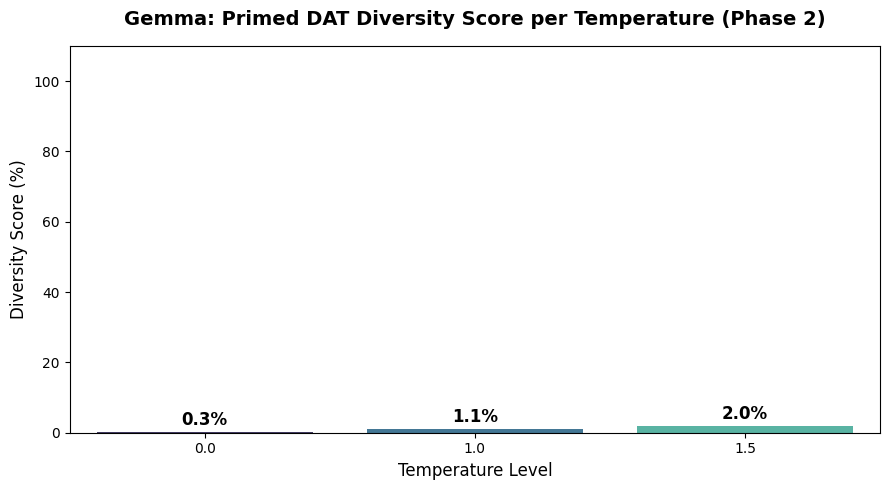

In [27]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from IPython.display import display

# Path adjusted for the Gemma output directory
MAIN_PATH = "/Users/precioux/Desktop/Projects/Creativity/code/Server/Fractals/results/Gemma3-26b/main_results.jsonl"

print("Gemma Model: Phase 2 (Primed DAT) - Word Diversity Analysis\n" + "="*60)

if Path(MAIN_PATH).exists():
    df_main = pd.read_json(MAIN_PATH, lines=True)
    
    # Filter and extract exactly 10 words for valid DAT runs in Phase 2
    def get_valid_words(parsed_data):
        if isinstance(parsed_data, dict) and 'words' in parsed_data:
            if isinstance(parsed_data['words'], list) and len(parsed_data['words']) == 10:
                return [str(w).strip().lower() for w in parsed_data['words']]
        return None

    df_main['valid_words'] = df_main['dat_parsed'].apply(get_valid_words)
    df_success = df_main[df_main['valid_words'].notnull()].copy()
    
    analysis_results = []
    temperatures = sorted(df_success['temperature'].unique())
    diversity_scores = []
    
    for temp in temperatures:
        temp_df = df_success[df_success['temperature'] == temp]
        total_valid_runs = len(temp_df)
        
        all_words = []
        for word_list in temp_df['valid_words']:
            all_words.extend(word_list)
            
        total_words = len(all_words)
        unique_words = len(set(all_words))
        
        # Calculate Diversity Score for Phase 2
        diversity_score = (unique_words / total_words * 100) if total_words > 0 else 0
        diversity_scores.append(diversity_score)
        
        analysis_results.append({
            "Temperature": temp,
            "Valid Runs": total_valid_runs,
            "Total Words": total_words,
            "Unique Words": unique_words,
            "Diversity Score (%)": f"{diversity_score:.1f}%"
        })

    # ==========================================
    # Display the Summary Table
    # ==========================================
    df_analysis = pd.DataFrame(analysis_results)
    styled_df = df_analysis.style.set_properties(**{'text-align': 'center'}).set_table_styles(
        [dict(selector='th', props=[('text-align', 'center'), ('font-weight', 'bold'), ('background-color', '#1e3799'), ('color', 'white')])]
    )
    display(styled_df)
    
    # ==========================================
    # Plotting the Bar Chart
    # ==========================================
    plt.style.use('default')
    plt.figure(figsize=(9, 5))
    
    ax = sns.barplot(x=temperatures, y=diversity_scores, palette="mako")
    
    plt.title('Gemma: Primed DAT Diversity Score per Temperature (Phase 2)', fontsize=14, fontweight='bold', pad=15)
    plt.xlabel('Temperature Level', fontsize=12)
    plt.ylabel('Diversity Score (%)', fontsize=12)
    plt.ylim(0, 110)
    
    for i, score in enumerate(diversity_scores):
        ax.text(i, score + 2, f"{score:.1f}%", ha='center', fontsize=12, fontweight='bold')
        
    plt.tight_layout()
    plt.show()

else:
    print(f"ERROR: Could not find the file at {MAIN_PATH}")

## Claude

Claude Opus 4.7: Analyzing DAT Baseline (Phase 1)


,Temperature,Success Rate,Total Words,Unique Words,Diversity Score (%)
0,0.000000,10 / 10,100,37,37.0%
1,1.000000,10 / 10,100,40,40.0%
2,1.500000,10 / 10,100,39,39.0%


/var/folders/_m/qyd_78r54hlc3qlgxy6q01qm0000gn/T/ipykernel_31099/172154234.py:60: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x=temperatures, y=diversity_scores, palette="magma")


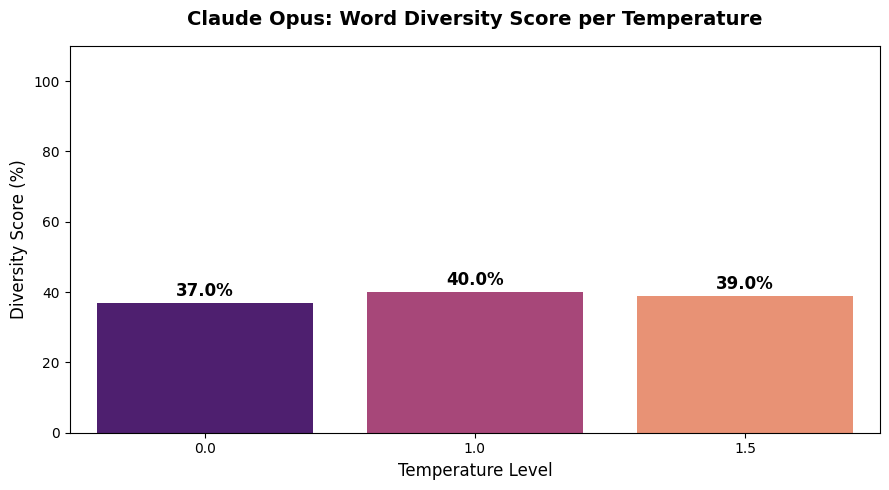

In [21]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from IPython.display import display

# Path adjusted for the Claude Opus output directory
BASELINE_PATH = "/Users/precioux/Desktop/Projects/Creativity/code/Server/Fractals/results/Claude-Opus-4-7/dat_baseline_results.jsonl"

print("Claude Opus 4.7: Analyzing DAT Baseline (Phase 1)\n" + "="*60)

if Path(BASELINE_PATH).exists():
    df_base = pd.read_json(BASELINE_PATH, lines=True)
    
    def check_success(parsed_data):
        if isinstance(parsed_data, dict) and 'words' in parsed_data:
            if isinstance(parsed_data['words'], list) and len(parsed_data['words']) == 10:
                return True
        return False

    df_base['is_successful'] = df_base['dat_parsed'].apply(check_success)
    
    analysis_results = []
    temperatures = sorted(df_base['temperature'].unique())
    diversity_scores = []
    
    for temp in temperatures:
        temp_df = df_base[(df_base['temperature'] == temp) & (df_base['is_successful'] == True)]
        total_runs = len(df_base[df_base['temperature'] == temp])
        success_runs = len(temp_df)
        
        all_words = []
        for words_list in temp_df['dat_parsed'].apply(lambda x: x['words']):
            cleaned = [str(w).strip().lower() for w in words_list]
            all_words.extend(cleaned)
            
        total_words = len(all_words)
        unique_words = len(set(all_words))
        diversity_score = (unique_words / total_words * 100) if total_words > 0 else 0
        diversity_scores.append(diversity_score)
        
        analysis_results.append({
            "Temperature": temp,
            "Success Rate": f"{success_runs} / {total_runs}",
            "Total Words": total_words,
            "Unique Words": unique_words,
            "Diversity Score (%)": f"{diversity_score:.1f}%"
        })

    # Display Table
    df_analysis = pd.DataFrame(analysis_results)
    styled_df = df_analysis.style.set_properties(**{'text-align': 'center'}).set_table_styles(
        [dict(selector='th', props=[('text-align', 'center'), ('font-weight', 'bold'), ('background-color', '#4a235a'), ('color', 'white')])]
    )
    display(styled_df)
    
    # Draw Bar Chart
    plt.style.use('default')
    plt.figure(figsize=(9, 5))
    ax = sns.barplot(x=temperatures, y=diversity_scores, palette="magma")
    plt.title('Claude Opus: Word Diversity Score per Temperature', fontsize=14, fontweight='bold', pad=15)
    plt.xlabel('Temperature Level', fontsize=12)
    plt.ylabel('Diversity Score (%)', fontsize=12)
    plt.ylim(0, 110)
    
    for i, score in enumerate(diversity_scores):
        ax.text(i, score + 2, f"{score:.1f}%", ha='center', fontsize=12, fontweight='bold')
        
    plt.tight_layout()
    plt.show()

else:
    print(f"ERROR: Could not find the file at {BASELINE_PATH}")

Claude Opus 4.7: Main Experiment Analysis (Phase 2)


,Temperature,Total Requests,Failed (Invalid JSON),Valid JSON (Total),Success: Found Shapes,Success: Found ZERO Shapes
0,0.000000,1608,0,1608,1608 (100.0%),0 (0.0%)
1,1.000000,1608,0,1608,1608 (100.0%),0 (0.0%)
2,1.500000,1610,0,1610,1610 (100.0%),0 (0.0%)



Table Legend:
- Failed (Invalid JSON): The model returned corrupted JSON. These tests are discarded.
- Success: Found ZERO Shapes: Valid JSON, but found no shapes in the image.



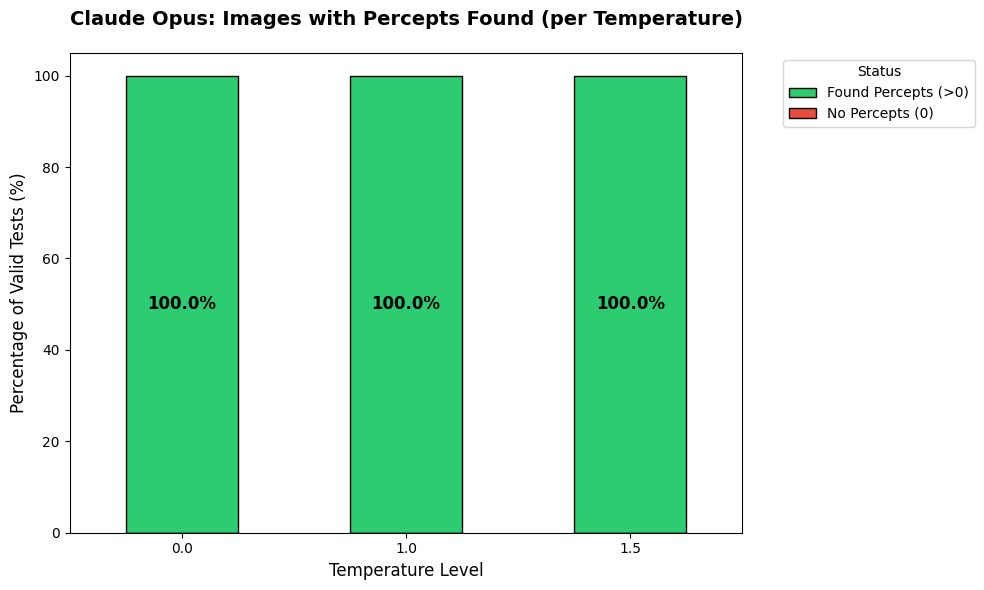

In [22]:
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from IPython.display import display

# Path adjusted for the Claude Opus output directory
MAIN_PATH = "/Users/precioux/Desktop/Projects/Creativity/code/Server/Fractals/results/Claude-Opus-4-7/main_results.jsonl"

print("Claude Opus 4.7: Main Experiment Analysis (Phase 2)\n" + "="*60)

if Path(MAIN_PATH).exists():
    df_main = pd.read_json(MAIN_PATH, lines=True)
    
    def check_percepts(parsed_data):
        if isinstance(parsed_data, dict) and 'percepts' in parsed_data:
            return len(parsed_data['percepts']) > 0
        return False

    summary_data = []
    
    # 1. Generate Summary Table
    for temp in sorted(df_main['temperature'].unique()):
        temp_df = df_main[df_main['temperature'] == temp]
        total_runs = len(temp_df)
        
        success_mask = temp_df['fractal_parsed'].notnull() & temp_df['dat_parsed'].notnull()
        valid_json_count = success_mask.sum()
        failed_count = total_runs - valid_json_count
        
        successful_df = temp_df[success_mask].copy()
        successful_df['found_percept'] = successful_df['fractal_parsed'].apply(check_percepts)
        
        found_count = successful_df['found_percept'].sum()
        not_found_count = valid_json_count - found_count
        
        found_pct = (found_count / valid_json_count * 100) if valid_json_count > 0 else 0
        not_found_pct = (not_found_count / valid_json_count * 100) if valid_json_count > 0 else 0
        
        summary_data.append({
            "Temperature": temp,
            "Total Requests": total_runs,
            "Failed (Invalid JSON)": failed_count,
            "Valid JSON (Total)": valid_json_count,
            "Success: Found Shapes": f"{found_count} ({found_pct:.1f}%)",
            "Success: Found ZERO Shapes": f"{not_found_count} ({not_found_pct:.1f}%)"
        })
        
    df_summary = pd.DataFrame(summary_data)
    styled_df = df_summary.style.set_properties(**{'text-align': 'center'}).set_table_styles(
        [dict(selector='th', props=[('text-align', 'center'), ('font-weight', 'bold'), ('background-color', '#2c3e50'), ('color', 'white')])]
    )
    display(styled_df)
    
    print("\nTable Legend:")
    print("- Failed (Invalid JSON): The model returned corrupted JSON. These tests are discarded.")
    print("- Success: Found ZERO Shapes: Valid JSON, but found no shapes in the image.\n")

    # 2. Prepare Data for Stacked Bar Chart
    df_success = df_main[df_main['fractal_parsed'].notnull() & df_main['dat_parsed'].notnull()].copy()
    df_success['found_percept'] = df_success['fractal_parsed'].apply(check_percepts)
    
    summary_chart = df_success.groupby('temperature')['found_percept'].value_counts(normalize=True).unstack().fillna(0) * 100
    if True not in summary_chart.columns: summary_chart[True] = 0.0
    if False not in summary_chart.columns: summary_chart[False] = 0.0
    
    summary_chart = summary_chart.rename(columns={True: 'Found Percepts (>0)', False: 'No Percepts (0)'})
    summary_chart = summary_chart[['Found Percepts (>0)', 'No Percepts (0)']]

    # 3. Draw Stacked Bar Chart
    plt.style.use('default') 
    fig, ax = plt.subplots(figsize=(10, 6))
    
    summary_chart.plot(kind='bar', stacked=True, color=['#2ecc71', '#e74c3c'], width=0.5, ax=ax, edgecolor='black')
    
    plt.title('Claude Opus: Images with Percepts Found (per Temperature)', fontsize=14, fontweight='bold', pad=20)
    plt.xlabel('Temperature Level', fontsize=12)
    plt.ylabel('Percentage of Valid Tests (%)', fontsize=12)
    plt.xticks(rotation=0)
    plt.legend(title='Status', bbox_to_anchor=(1.05, 1), loc='upper left')

    for p in ax.patches:
        width, height = p.get_width(), p.get_height()
        x, y = p.get_xy() 
        if height > 0.0:
            ax.text(x + width/2, y + height/2, f'{height:.1f}%', ha='center', va='center', fontsize=12, fontweight='bold', color='black')

    plt.tight_layout()
    plt.show()

else:
    print(f"ERROR: Could not find the file at {MAIN_PATH}")

Claude Opus 4.7: Phase 2 (Primed DAT) - Word Diversity Analysis


,Temperature,Valid Runs,Total Words,Unique Words,Diversity Score (%)
0,0.000000,1608,16080,426,2.6%
1,1.000000,1608,16080,403,2.5%
2,1.500000,1610,16100,408,2.5%


/var/folders/_m/qyd_78r54hlc3qlgxy6q01qm0000gn/T/ipykernel_31099/270339920.py:67: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x=temperatures, y=diversity_scores, palette="magma")


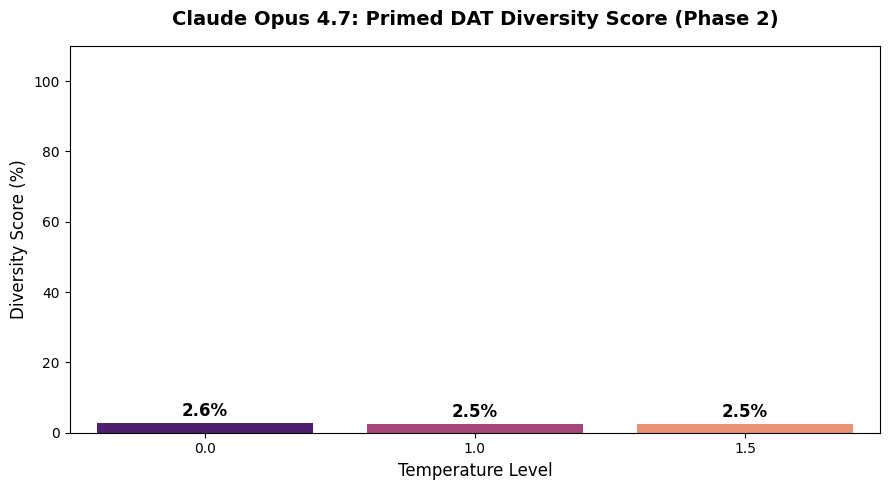

In [28]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from IPython.display import display

# Path adjusted for the Claude Opus 4.7 output directory
MAIN_PATH = "/Users/precioux/Desktop/Projects/Creativity/code/Server/Fractals/results/Claude-Opus-4-7/main_results.jsonl"

print("Claude Opus 4.7: Phase 2 (Primed DAT) - Word Diversity Analysis\n" + "="*65)

if Path(MAIN_PATH).exists():
    df_main = pd.read_json(MAIN_PATH, lines=True)
    
    # Filter and extract exactly 10 words for valid DAT runs in Phase 2
    def get_valid_words(parsed_data):
        if isinstance(parsed_data, dict) and 'words' in parsed_data:
            if isinstance(parsed_data['words'], list) and len(parsed_data['words']) == 10:
                return [str(w).strip().lower() for w in parsed_data['words']]
        return None

    df_main['valid_words'] = df_main['dat_parsed'].apply(get_valid_words)
    df_success = df_main[df_main['valid_words'].notnull()].copy()
    
    analysis_results = []
    temperatures = sorted(df_success['temperature'].unique())
    diversity_scores = []
    
    for temp in temperatures:
        temp_df = df_success[df_success['temperature'] == temp]
        total_valid_runs = len(temp_df)
        
        all_words = []
        for word_list in temp_df['valid_words']:
            all_words.extend(word_list)
            
        total_words = len(all_words)
        unique_words = len(set(all_words))
        
        # Calculate Diversity Score for Phase 2
        diversity_score = (unique_words / total_words * 100) if total_words > 0 else 0
        diversity_scores.append(diversity_score)
        
        analysis_results.append({
            "Temperature": temp,
            "Valid Runs": total_valid_runs,
            "Total Words": total_words,
            "Unique Words": unique_words,
            "Diversity Score (%)": f"{diversity_score:.1f}%"
        })

    # ==========================================
    # Display the Summary Table
    # ==========================================
    df_analysis = pd.DataFrame(analysis_results)
    styled_df = df_analysis.style.set_properties(**{'text-align': 'center'}).set_table_styles(
        [dict(selector='th', props=[('text-align', 'center'), ('font-weight', 'bold'), ('background-color', '#4a235a'), ('color', 'white')])]
    )
    display(styled_df)
    
    # ==========================================
    # Plotting the Bar Chart
    # ==========================================
    plt.style.use('default')
    plt.figure(figsize=(9, 5))
    
    ax = sns.barplot(x=temperatures, y=diversity_scores, palette="magma")
    
    plt.title('Claude Opus 4.7: Primed DAT Diversity Score (Phase 2)', fontsize=14, fontweight='bold', pad=15)
    plt.xlabel('Temperature Level', fontsize=12)
    plt.ylabel('Diversity Score (%)', fontsize=12)
    plt.ylim(0, 110)
    
    for i, score in enumerate(diversity_scores):
        ax.text(i, score + 2, f"{score:.1f}%", ha='center', fontsize=12, fontweight='bold')
        
    plt.tight_layout()
    plt.show()

else:
    print(f"ERROR: Could not find the file at {MAIN_PATH}")

## GPT

GPT-5.4: Analyzing DAT Baseline (Phase 1)


,Temperature,Success Rate,Total Words,Unique Words,Diversity Score (%)
0,0.000000,10 / 10,100,36,36.0%
1,1.000000,10 / 10,100,36,36.0%
2,1.500000,10 / 10,100,41,41.0%


/var/folders/_m/qyd_78r54hlc3qlgxy6q01qm0000gn/T/ipykernel_31099/4108884365.py:60: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x=temperatures, y=diversity_scores, palette="crest")


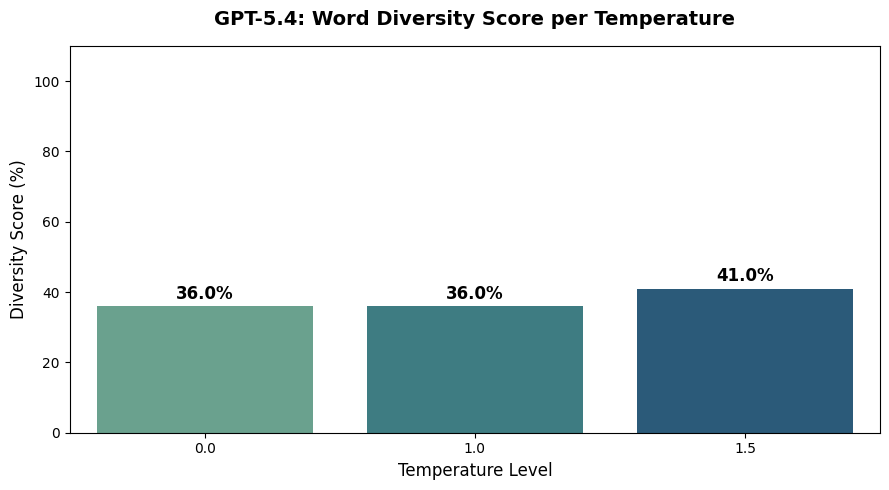

In [31]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from IPython.display import display

# Path adjusted for the GPT-5.4 output directory
BASELINE_PATH = "/Users/precioux/Desktop/Projects/Creativity/code/Server/Fractals/results/GPT-5.4/dat_baseline_results.jsonl"

print("GPT-5.4: Analyzing DAT Baseline (Phase 1)\n" + "="*60)

if Path(BASELINE_PATH).exists():
    df_base = pd.read_json(BASELINE_PATH, lines=True)
    
    def check_success(parsed_data):
        if isinstance(parsed_data, dict) and 'words' in parsed_data:
            if isinstance(parsed_data['words'], list) and len(parsed_data['words']) == 10:
                return True
        return False

    df_base['is_successful'] = df_base['dat_parsed'].apply(check_success)
    
    analysis_results = []
    temperatures = sorted(df_base['temperature'].unique())
    diversity_scores = []
    
    for temp in temperatures:
        temp_df = df_base[(df_base['temperature'] == temp) & (df_base['is_successful'] == True)]
        total_runs = len(df_base[df_base['temperature'] == temp])
        success_runs = len(temp_df)
        
        all_words = []
        for words_list in temp_df['dat_parsed'].apply(lambda x: x['words']):
            cleaned = [str(w).strip().lower() for w in words_list]
            all_words.extend(cleaned)
            
        total_words = len(all_words)
        unique_words = len(set(all_words))
        diversity_score = (unique_words / total_words * 100) if total_words > 0 else 0
        diversity_scores.append(diversity_score)
        
        analysis_results.append({
            "Temperature": temp,
            "Success Rate": f"{success_runs} / {total_runs}",
            "Total Words": total_words,
            "Unique Words": unique_words,
            "Diversity Score (%)": f"{diversity_score:.1f}%"
        })

    # Display Table
    df_analysis = pd.DataFrame(analysis_results)
    styled_df = df_analysis.style.set_properties(**{'text-align': 'center'}).set_table_styles(
        [dict(selector='th', props=[('text-align', 'center'), ('font-weight', 'bold'), ('background-color', '#1e8449'), ('color', 'white')])]
    )
    display(styled_df)
    
    # Draw Bar Chart
    plt.style.use('default')
    plt.figure(figsize=(9, 5))
    ax = sns.barplot(x=temperatures, y=diversity_scores, palette="crest")
    plt.title('GPT-5.4: Word Diversity Score per Temperature', fontsize=14, fontweight='bold', pad=15)
    plt.xlabel('Temperature Level', fontsize=12)
    plt.ylabel('Diversity Score (%)', fontsize=12)
    plt.ylim(0, 110)
    
    for i, score in enumerate(diversity_scores):
        ax.text(i, score + 2, f"{score:.1f}%", ha='center', fontsize=12, fontweight='bold')
        
    plt.tight_layout()
    plt.show()

else:
    print(f"ERROR: Could not find the file at {BASELINE_PATH}")

GPT-5.4: Main Experiment Analysis (Phase 2)


,Temperature,Total Requests,Failed (Invalid JSON),Valid JSON (Total),Success: Found Shapes,Success: Found ZERO Shapes
0,0.000000,1610,0,1610,1610 (100.0%),0 (0.0%)
1,1.000000,1424,0,1424,1424 (100.0%),0 (0.0%)
2,1.500000,1578,0,1578,1578 (100.0%),0 (0.0%)



Table Legend:
- Failed (Invalid JSON): The model returned corrupted JSON. These tests are discarded.
- Success: Found ZERO Shapes: Valid JSON, but found no shapes in the image.



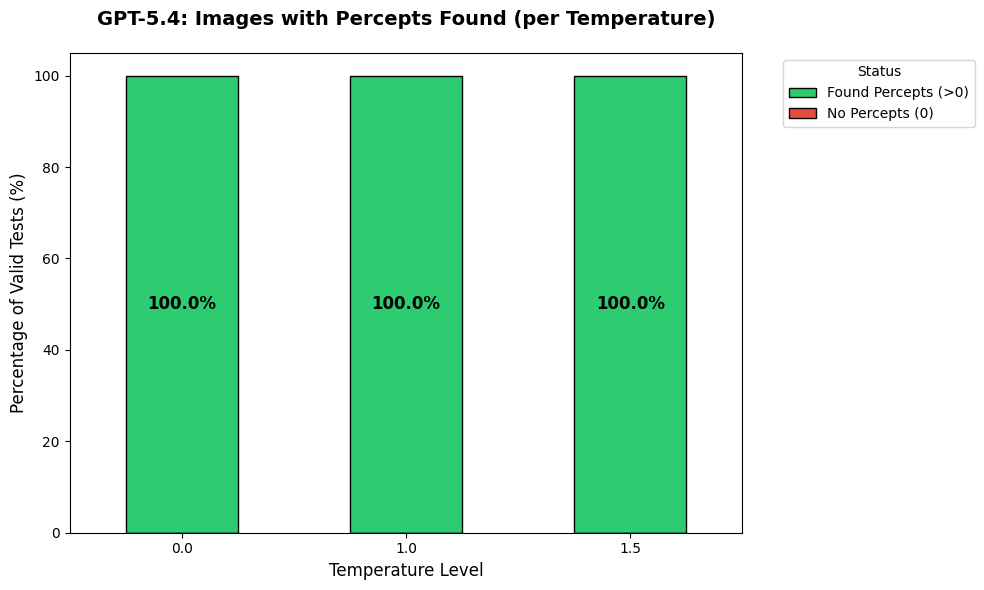

In [30]:
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from IPython.display import display

# Path adjusted for the GPT-5.4 output directory
MAIN_PATH = "/Users/precioux/Desktop/Projects/Creativity/code/Server/Fractals/results/GPT-5.4/main_results.jsonl"

print("GPT-5.4: Main Experiment Analysis (Phase 2)\n" + "="*60)

if Path(MAIN_PATH).exists():
    df_main = pd.read_json(MAIN_PATH, lines=True)
    
    def check_percepts(parsed_data):
        if isinstance(parsed_data, dict) and 'percepts' in parsed_data:
            return len(parsed_data['percepts']) > 0
        return False

    summary_data = []
    
    # 1. Generate Summary Table
    for temp in sorted(df_main['temperature'].unique()):
        temp_df = df_main[df_main['temperature'] == temp]
        total_runs = len(temp_df)
        
        success_mask = temp_df['fractal_parsed'].notnull() & temp_df['dat_parsed'].notnull()
        valid_json_count = success_mask.sum()
        failed_count = total_runs - valid_json_count
        
        successful_df = temp_df[success_mask].copy()
        successful_df['found_percept'] = successful_df['fractal_parsed'].apply(check_percepts)
        
        found_count = successful_df['found_percept'].sum()
        not_found_count = valid_json_count - found_count
        
        found_pct = (found_count / valid_json_count * 100) if valid_json_count > 0 else 0
        not_found_pct = (not_found_count / valid_json_count * 100) if valid_json_count > 0 else 0
        
        summary_data.append({
            "Temperature": temp,
            "Total Requests": total_runs,
            "Failed (Invalid JSON)": failed_count,
            "Valid JSON (Total)": valid_json_count,
            "Success: Found Shapes": f"{found_count} ({found_pct:.1f}%)",
            "Success: Found ZERO Shapes": f"{not_found_count} ({not_found_pct:.1f}%)"
        })
        
    df_summary = pd.DataFrame(summary_data)
    styled_df = df_summary.style.set_properties(**{'text-align': 'center'}).set_table_styles(
        [dict(selector='th', props=[('text-align', 'center'), ('font-weight', 'bold'), ('background-color', '#2c3e50'), ('color', 'white')])]
    )
    display(styled_df)
    
    print("\nTable Legend:")
    print("- Failed (Invalid JSON): The model returned corrupted JSON. These tests are discarded.")
    print("- Success: Found ZERO Shapes: Valid JSON, but found no shapes in the image.\n")

    # 2. Prepare Data for Stacked Bar Chart
    df_success = df_main[df_main['fractal_parsed'].notnull() & df_main['dat_parsed'].notnull()].copy()
    df_success['found_percept'] = df_success['fractal_parsed'].apply(check_percepts)
    
    summary_chart = df_success.groupby('temperature')['found_percept'].value_counts(normalize=True).unstack().fillna(0) * 100
    if True not in summary_chart.columns: summary_chart[True] = 0.0
    if False not in summary_chart.columns: summary_chart[False] = 0.0
    
    summary_chart = summary_chart.rename(columns={True: 'Found Percepts (>0)', False: 'No Percepts (0)'})
    summary_chart = summary_chart[['Found Percepts (>0)', 'No Percepts (0)']]

    # 3. Draw Stacked Bar Chart
    plt.style.use('default') 
    fig, ax = plt.subplots(figsize=(10, 6))
    
    summary_chart.plot(kind='bar', stacked=True, color=['#2ecc71', '#e74c3c'], width=0.5, ax=ax, edgecolor='black')
    
    plt.title('GPT-5.4: Images with Percepts Found (per Temperature)', fontsize=14, fontweight='bold', pad=20)
    plt.xlabel('Temperature Level', fontsize=12)
    plt.ylabel('Percentage of Valid Tests (%)', fontsize=12)
    plt.xticks(rotation=0)
    plt.legend(title='Status', bbox_to_anchor=(1.05, 1), loc='upper left')

    for p in ax.patches:
        width, height = p.get_width(), p.get_height()
        x, y = p.get_xy() 
        if height > 0.0:
            ax.text(x + width/2, y + height/2, f'{height:.1f}%', ha='center', va='center', fontsize=12, fontweight='bold', color='black')

    plt.tight_layout()
    plt.show()

else:
    print(f"ERROR: Could not find the file at {MAIN_PATH}")

GPT-5.4: Phase 2 (Primed DAT) - Word Diversity Analysis


,Temperature,Valid Runs,Total Words,Unique Words,Diversity Score (%)
0,0.000000,1610,16100,162,1.0%
1,1.000000,1424,14240,158,1.1%
2,1.500000,1578,15780,159,1.0%


/var/folders/_m/qyd_78r54hlc3qlgxy6q01qm0000gn/T/ipykernel_31099/2309587817.py:67: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x=temperatures, y=diversity_scores, palette="crest")


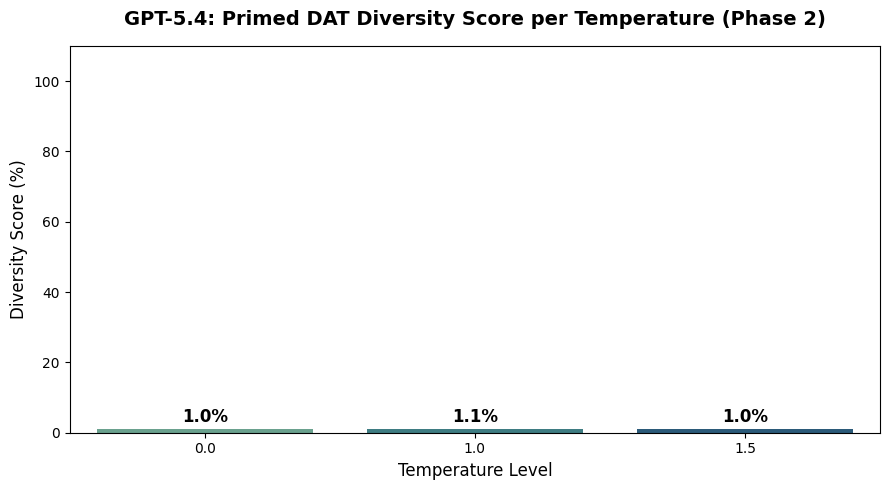

In [29]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from IPython.display import display

# Path adjusted for the GPT-5.4 output directory
MAIN_PATH = "/Users/precioux/Desktop/Projects/Creativity/code/Server/Fractals/results/GPT-5.4/main_results.jsonl"

print("GPT-5.4: Phase 2 (Primed DAT) - Word Diversity Analysis\n" + "="*60)

if Path(MAIN_PATH).exists():
    df_main = pd.read_json(MAIN_PATH, lines=True)
    
    # Filter and extract exactly 10 words for valid DAT runs in Phase 2
    def get_valid_words(parsed_data):
        if isinstance(parsed_data, dict) and 'words' in parsed_data:
            if isinstance(parsed_data['words'], list) and len(parsed_data['words']) == 10:
                return [str(w).strip().lower() for w in parsed_data['words']]
        return None

    df_main['valid_words'] = df_main['dat_parsed'].apply(get_valid_words)
    df_success = df_main[df_main['valid_words'].notnull()].copy()
    
    analysis_results = []
    temperatures = sorted(df_success['temperature'].unique())
    diversity_scores = []
    
    for temp in temperatures:
        temp_df = df_success[df_success['temperature'] == temp]
        total_valid_runs = len(temp_df)
        
        all_words = []
        for word_list in temp_df['valid_words']:
            all_words.extend(word_list)
            
        total_words = len(all_words)
        unique_words = len(set(all_words))
        
        # Calculate Diversity Score for Phase 2
        diversity_score = (unique_words / total_words * 100) if total_words > 0 else 0
        diversity_scores.append(diversity_score)
        
        analysis_results.append({
            "Temperature": temp,
            "Valid Runs": total_valid_runs,
            "Total Words": total_words,
            "Unique Words": unique_words,
            "Diversity Score (%)": f"{diversity_score:.1f}%"
        })

    # ==========================================
    # Display the Summary Table
    # ==========================================
    df_analysis = pd.DataFrame(analysis_results)
    styled_df = df_analysis.style.set_properties(**{'text-align': 'center'}).set_table_styles(
        [dict(selector='th', props=[('text-align', 'center'), ('font-weight', 'bold'), ('background-color', '#1e8449'), ('color', 'white')])]
    )
    display(styled_df)
    
    # ==========================================
    # Plotting the Bar Chart
    # ==========================================
    plt.style.use('default')
    plt.figure(figsize=(9, 5))
    
    ax = sns.barplot(x=temperatures, y=diversity_scores, palette="crest")
    
    plt.title('GPT-5.4: Primed DAT Diversity Score per Temperature (Phase 2)', fontsize=14, fontweight='bold', pad=15)
    plt.xlabel('Temperature Level', fontsize=12)
    plt.ylabel('Diversity Score (%)', fontsize=12)
    plt.ylim(0, 110)
    
    for i, score in enumerate(diversity_scores):
        ax.text(i, score + 2, f"{score:.1f}%", ha='center', fontsize=12, fontweight='bold')
        
    plt.tight_layout()
    plt.show()

else:
    print(f"ERROR: Could not find the file at {MAIN_PATH}")

## Mistral

Mistral Small 4: Analyzing DAT Baseline (Phase 1)


,Temperature,Success Rate,Total Words,Unique Words,Diversity Score (%)
0,0.000000,10 / 10,100,32,32.0%
1,1.000000,10 / 10,100,56,56.0%
2,1.500000,10 / 10,100,62,62.0%


/var/folders/_m/qyd_78r54hlc3qlgxy6q01qm0000gn/T/ipykernel_31099/1087421842.py:60: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x=temperatures, y=diversity_scores, palette="Oranges_r")


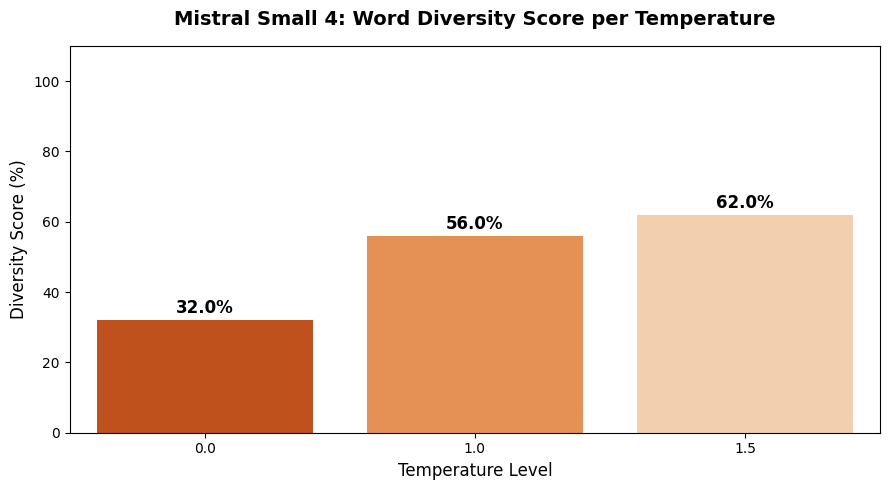

In [32]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from IPython.display import display

# Path adjusted for the Mistral output directory
BASELINE_PATH = "/Users/precioux/Desktop/Projects/Creativity/code/Server/Fractals/results/Mistral-Small-4/dat_baseline_results.jsonl"

print("Mistral Small 4: Analyzing DAT Baseline (Phase 1)\n" + "="*60)

if Path(BASELINE_PATH).exists():
    df_base = pd.read_json(BASELINE_PATH, lines=True)
    
    def check_success(parsed_data):
        if isinstance(parsed_data, dict) and 'words' in parsed_data:
            if isinstance(parsed_data['words'], list) and len(parsed_data['words']) == 10:
                return True
        return False

    df_base['is_successful'] = df_base['dat_parsed'].apply(check_success)
    
    analysis_results = []
    temperatures = sorted(df_base['temperature'].unique())
    diversity_scores = []
    
    for temp in temperatures:
        temp_df = df_base[(df_base['temperature'] == temp) & (df_base['is_successful'] == True)]
        total_runs = len(df_base[df_base['temperature'] == temp])
        success_runs = len(temp_df)
        
        all_words = []
        for words_list in temp_df['dat_parsed'].apply(lambda x: x['words']):
            cleaned = [str(w).strip().lower() for w in words_list]
            all_words.extend(cleaned)
            
        total_words = len(all_words)
        unique_words = len(set(all_words))
        diversity_score = (unique_words / total_words * 100) if total_words > 0 else 0
        diversity_scores.append(diversity_score)
        
        analysis_results.append({
            "Temperature": temp,
            "Success Rate": f"{success_runs} / {total_runs}",
            "Total Words": total_words,
            "Unique Words": unique_words,
            "Diversity Score (%)": f"{diversity_score:.1f}%"
        })

    # Display Table
    df_analysis = pd.DataFrame(analysis_results)
    styled_df = df_analysis.style.set_properties(**{'text-align': 'center'}).set_table_styles(
        [dict(selector='th', props=[('text-align', 'center'), ('font-weight', 'bold'), ('background-color', '#d35400'), ('color', 'white')])]
    )
    display(styled_df)
    
    # Draw Bar Chart
    plt.style.use('default')
    plt.figure(figsize=(9, 5))
    ax = sns.barplot(x=temperatures, y=diversity_scores, palette="Oranges_r")
    plt.title('Mistral Small 4: Word Diversity Score per Temperature', fontsize=14, fontweight='bold', pad=15)
    plt.xlabel('Temperature Level', fontsize=12)
    plt.ylabel('Diversity Score (%)', fontsize=12)
    plt.ylim(0, 110)
    
    for i, score in enumerate(diversity_scores):
        ax.text(i, score + 2, f"{score:.1f}%", ha='center', fontsize=12, fontweight='bold')
        
    plt.tight_layout()
    plt.show()

else:
    print(f"ERROR: Could not find the file at {BASELINE_PATH}")

Mistral Small 4: Main Experiment Analysis (Phase 2)


,Temperature,Total Requests,Failed (Invalid JSON),Valid JSON (Total),Success: Found Shapes,Success: Found ZERO Shapes
0,0.000000,1610,0,1610,121 (7.5%),1489 (92.5%)
1,1.000000,1610,4,1606,382 (23.8%),1224 (76.2%)
2,1.500000,1610,12,1598,366 (22.9%),1232 (77.1%)



Table Legend:
- Failed (Invalid JSON): The model returned corrupted JSON. These tests are discarded.
- Success: Found ZERO Shapes: Valid JSON, but found no shapes in the image.



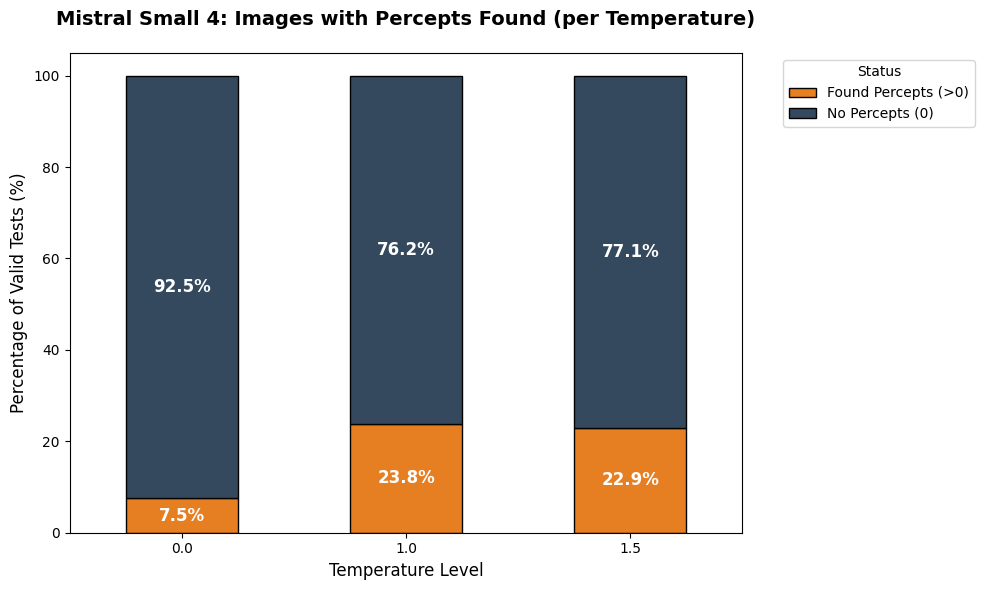

In [33]:
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from IPython.display import display

# Path adjusted for the Mistral output directory
MAIN_PATH = "/Users/precioux/Desktop/Projects/Creativity/code/Server/Fractals/results/Mistral-Small-4/main_results.jsonl"

print("Mistral Small 4: Main Experiment Analysis (Phase 2)\n" + "="*60)

if Path(MAIN_PATH).exists():
    df_main = pd.read_json(MAIN_PATH, lines=True)
    
    def check_percepts(parsed_data):
        if isinstance(parsed_data, dict) and 'percepts' in parsed_data:
            return len(parsed_data['percepts']) > 0
        return False

    summary_data = []
    
    # 1. Generate Summary Table
    for temp in sorted(df_main['temperature'].unique()):
        temp_df = df_main[df_main['temperature'] == temp]
        total_runs = len(temp_df)
        
        success_mask = temp_df['fractal_parsed'].notnull() & temp_df['dat_parsed'].notnull()
        valid_json_count = success_mask.sum()
        failed_count = total_runs - valid_json_count
        
        successful_df = temp_df[success_mask].copy()
        successful_df['found_percept'] = successful_df['fractal_parsed'].apply(check_percepts)
        
        found_count = successful_df['found_percept'].sum()
        not_found_count = valid_json_count - found_count
        
        found_pct = (found_count / valid_json_count * 100) if valid_json_count > 0 else 0
        not_found_pct = (not_found_count / valid_json_count * 100) if valid_json_count > 0 else 0
        
        summary_data.append({
            "Temperature": temp,
            "Total Requests": total_runs,
            "Failed (Invalid JSON)": failed_count,
            "Valid JSON (Total)": valid_json_count,
            "Success: Found Shapes": f"{found_count} ({found_pct:.1f}%)",
            "Success: Found ZERO Shapes": f"{not_found_count} ({not_found_pct:.1f}%)"
        })
        
    df_summary = pd.DataFrame(summary_data)
    styled_df = df_summary.style.set_properties(**{'text-align': 'center'}).set_table_styles(
        [dict(selector='th', props=[('text-align', 'center'), ('font-weight', 'bold'), ('background-color', '#2c3e50'), ('color', 'white')])]
    )
    display(styled_df)
    
    print("\nTable Legend:")
    print("- Failed (Invalid JSON): The model returned corrupted JSON. These tests are discarded.")
    print("- Success: Found ZERO Shapes: Valid JSON, but found no shapes in the image.\n")

    # 2. Prepare Data for Stacked Bar Chart
    df_success = df_main[df_main['fractal_parsed'].notnull() & df_main['dat_parsed'].notnull()].copy()
    df_success['found_percept'] = df_success['fractal_parsed'].apply(check_percepts)
    
    summary_chart = df_success.groupby('temperature')['found_percept'].value_counts(normalize=True).unstack().fillna(0) * 100
    if True not in summary_chart.columns: summary_chart[True] = 0.0
    if False not in summary_chart.columns: summary_chart[False] = 0.0
    
    summary_chart = summary_chart.rename(columns={True: 'Found Percepts (>0)', False: 'No Percepts (0)'})
    summary_chart = summary_chart[['Found Percepts (>0)', 'No Percepts (0)']]

    # 3. Draw Stacked Bar Chart
    plt.style.use('default') 
    fig, ax = plt.subplots(figsize=(10, 6))
    
    summary_chart.plot(kind='bar', stacked=True, color=['#e67e22', '#34495e'], width=0.5, ax=ax, edgecolor='black')
    
    plt.title('Mistral Small 4: Images with Percepts Found (per Temperature)', fontsize=14, fontweight='bold', pad=20)
    plt.xlabel('Temperature Level', fontsize=12)
    plt.ylabel('Percentage of Valid Tests (%)', fontsize=12)
    plt.xticks(rotation=0)
    plt.legend(title='Status', bbox_to_anchor=(1.05, 1), loc='upper left')

    for p in ax.patches:
        width, height = p.get_width(), p.get_height()
        x, y = p.get_xy() 
        if height > 0.0:
            ax.text(x + width/2, y + height/2, f'{height:.1f}%', ha='center', va='center', fontsize=12, fontweight='bold', color='white')

    plt.tight_layout()
    plt.show()

else:
    print(f"ERROR: Could not find the file at {MAIN_PATH}")

Mistral Small 4: Phase 2 (Primed DAT) - Word Diversity Analysis


,Temperature,Valid Runs,Total Words,Unique Words,Diversity Score (%)
0,0.000000,1610,16100,201,1.2%
1,1.000000,1608,16080,1346,8.4%
2,1.500000,1608,16080,1450,9.0%


/var/folders/_m/qyd_78r54hlc3qlgxy6q01qm0000gn/T/ipykernel_31099/3993287487.py:67: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x=temperatures, y=diversity_scores, palette="Oranges_r")


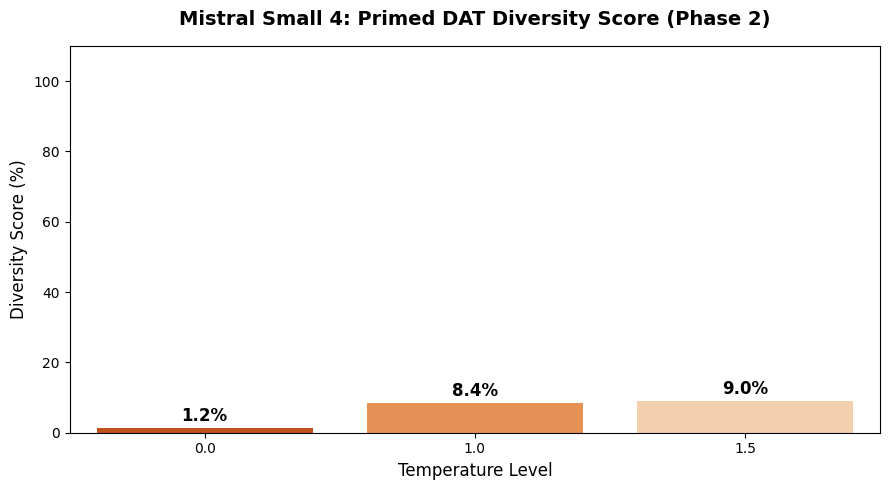

In [34]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from IPython.display import display

# Path adjusted for the Mistral output directory
MAIN_PATH = "/Users/precioux/Desktop/Projects/Creativity/code/Server/Fractals/results/Mistral-Small-4/main_results.jsonl"

print("Mistral Small 4: Phase 2 (Primed DAT) - Word Diversity Analysis\n" + "="*60)

if Path(MAIN_PATH).exists():
    df_main = pd.read_json(MAIN_PATH, lines=True)
    
    # Filter and extract exactly 10 words for valid DAT runs in Phase 2
    def get_valid_words(parsed_data):
        if isinstance(parsed_data, dict) and 'words' in parsed_data:
            if isinstance(parsed_data['words'], list) and len(parsed_data['words']) == 10:
                return [str(w).strip().lower() for w in parsed_data['words']]
        return None

    df_main['valid_words'] = df_main['dat_parsed'].apply(get_valid_words)
    df_success = df_main[df_main['valid_words'].notnull()].copy()
    
    analysis_results = []
    temperatures = sorted(df_success['temperature'].unique())
    diversity_scores = []
    
    for temp in temperatures:
        temp_df = df_success[df_success['temperature'] == temp]
        total_valid_runs = len(temp_df)
        
        all_words = []
        for word_list in temp_df['valid_words']:
            all_words.extend(word_list)
            
        total_words = len(all_words)
        unique_words = len(set(all_words))
        
        # Calculate Diversity Score for Phase 2
        diversity_score = (unique_words / total_words * 100) if total_words > 0 else 0
        diversity_scores.append(diversity_score)
        
        analysis_results.append({
            "Temperature": temp,
            "Valid Runs": total_valid_runs,
            "Total Words": total_words,
            "Unique Words": unique_words,
            "Diversity Score (%)": f"{diversity_score:.1f}%"
        })

    # ==========================================
    # Display the Summary Table
    # ==========================================
    df_analysis = pd.DataFrame(analysis_results)
    styled_df = df_analysis.style.set_properties(**{'text-align': 'center'}).set_table_styles(
        [dict(selector='th', props=[('text-align', 'center'), ('font-weight', 'bold'), ('background-color', '#d35400'), ('color', 'white')])]
    )
    display(styled_df)
    
    # ==========================================
    # Plotting the Bar Chart
    # ==========================================
    plt.style.use('default')
    plt.figure(figsize=(9, 5))
    
    ax = sns.barplot(x=temperatures, y=diversity_scores, palette="Oranges_r")
    
    plt.title('Mistral Small 4: Primed DAT Diversity Score (Phase 2)', fontsize=14, fontweight='bold', pad=15)
    plt.xlabel('Temperature Level', fontsize=12)
    plt.ylabel('Diversity Score (%)', fontsize=12)
    plt.ylim(0, 110)
    
    for i, score in enumerate(diversity_scores):
        ax.text(i, score + 2, f"{score:.1f}%", ha='center', fontsize=12, fontweight='bold')
        
    plt.tight_layout()
    plt.show()

else:
    print(f"ERROR: Could not find the file at {MAIN_PATH}")

## Qwen

Qwen3.5-9B: Analyzing DAT Baseline (Phase 1)


,Temperature,Success Rate,Total Words,Unique Words,Diversity Score (%)
0,0.000000,10 / 10,100,30,30.0%
1,1.000000,10 / 10,100,56,56.0%
2,1.500000,0 / 10,0,0,0.0%


/var/folders/_m/qyd_78r54hlc3qlgxy6q01qm0000gn/T/ipykernel_31099/210855678.py:60: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x=temperatures, y=diversity_scores, palette="Blues_r")


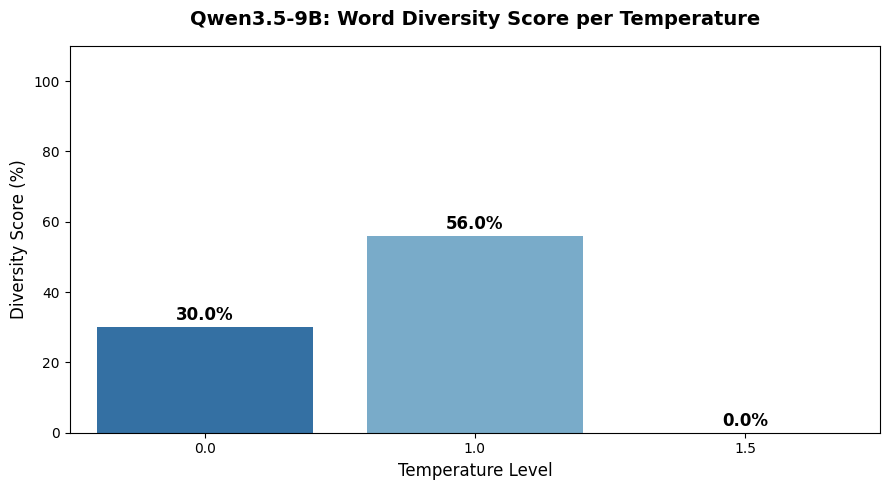

In [36]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from IPython.display import display

# Path adjusted for the Qwen3.5-9B output directory
BASELINE_PATH = "/Users/precioux/Desktop/Projects/Creativity/code/Server/Fractals/results/Qwen3.5-9B/dat_baseline_results.jsonl"

print("Qwen3.5-9B: Analyzing DAT Baseline (Phase 1)\n" + "="*60)

if Path(BASELINE_PATH).exists():
    df_base = pd.read_json(BASELINE_PATH, lines=True)
    
    def check_success(parsed_data):
        if isinstance(parsed_data, dict) and 'words' in parsed_data:
            if isinstance(parsed_data['words'], list) and len(parsed_data['words']) == 10:
                return True
        return False

    df_base['is_successful'] = df_base['dat_parsed'].apply(check_success)
    
    analysis_results = []
    temperatures = sorted(df_base['temperature'].unique())
    diversity_scores = []
    
    for temp in temperatures:
        temp_df = df_base[(df_base['temperature'] == temp) & (df_base['is_successful'] == True)]
        total_runs = len(df_base[df_base['temperature'] == temp])
        success_runs = len(temp_df)
        
        all_words = []
        for words_list in temp_df['dat_parsed'].apply(lambda x: x['words']):
            cleaned = [str(w).strip().lower() for w in words_list]
            all_words.extend(cleaned)
            
        total_words = len(all_words)
        unique_words = len(set(all_words))
        diversity_score = (unique_words / total_words * 100) if total_words > 0 else 0
        diversity_scores.append(diversity_score)
        
        analysis_results.append({
            "Temperature": temp,
            "Success Rate": f"{success_runs} / {total_runs}",
            "Total Words": total_words,
            "Unique Words": unique_words,
            "Diversity Score (%)": f"{diversity_score:.1f}%"
        })

    # Display Table
    df_analysis = pd.DataFrame(analysis_results)
    styled_df = df_analysis.style.set_properties(**{'text-align': 'center'}).set_table_styles(
        [dict(selector='th', props=[('text-align', 'center'), ('font-weight', 'bold'), ('background-color', '#2980b9'), ('color', 'white')])]
    )
    display(styled_df)
    
    # Draw Bar Chart
    plt.style.use('default')
    plt.figure(figsize=(9, 5))
    ax = sns.barplot(x=temperatures, y=diversity_scores, palette="Blues_r")
    plt.title('Qwen3.5-9B: Word Diversity Score per Temperature', fontsize=14, fontweight='bold', pad=15)
    plt.xlabel('Temperature Level', fontsize=12)
    plt.ylabel('Diversity Score (%)', fontsize=12)
    plt.ylim(0, 110)
    
    for i, score in enumerate(diversity_scores):
        ax.text(i, score + 2, f"{score:.1f}%", ha='center', fontsize=12, fontweight='bold')
        
    plt.tight_layout()
    plt.show()

else:
    print(f"ERROR: Could not find the file at {BASELINE_PATH}")

Qwen3.5-9B: Main Experiment Analysis (Phase 2)


,Temperature,Total Requests,Failed (Invalid JSON),Valid JSON (Total),Success: Found Shapes,Success: Found ZERO Shapes
0,0.000000,1609,4,1605,525 (32.7%),1080 (67.3%)
1,1.000000,1600,47,1553,712 (45.8%),841 (54.2%)
2,1.500000,1556,1368,188,38 (20.2%),150 (79.8%)



Table Legend:
- Failed (Invalid JSON): The model returned corrupted JSON. These tests are discarded.
- Success: Found ZERO Shapes: Valid JSON, but found no shapes in the image.



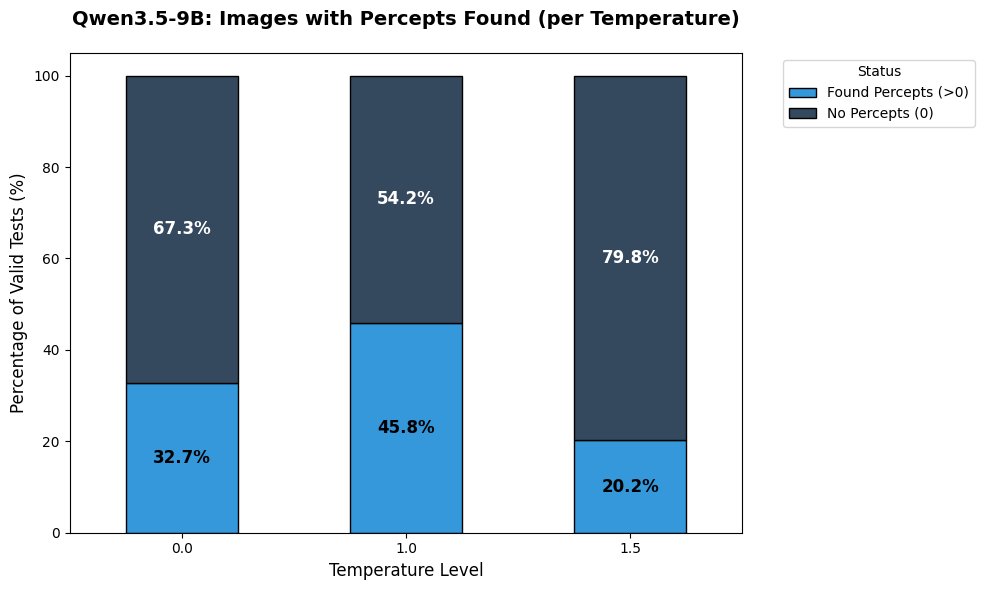

In [37]:
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from IPython.display import display

# Path adjusted for the Qwen3.5-9B output directory
MAIN_PATH = "/Users/precioux/Desktop/Projects/Creativity/code/Server/Fractals/results/Qwen3.5-9B/main_results.jsonl"

print("Qwen3.5-9B: Main Experiment Analysis (Phase 2)\n" + "="*60)

if Path(MAIN_PATH).exists():
    df_main = pd.read_json(MAIN_PATH, lines=True)
    
    def check_percepts(parsed_data):
        if isinstance(parsed_data, dict) and 'percepts' in parsed_data:
            return len(parsed_data['percepts']) > 0
        return False

    summary_data = []
    
    # 1. Generate Summary Table
    for temp in sorted(df_main['temperature'].unique()):
        temp_df = df_main[df_main['temperature'] == temp]
        total_runs = len(temp_df)
        
        success_mask = temp_df['fractal_parsed'].notnull() & temp_df['dat_parsed'].notnull()
        valid_json_count = success_mask.sum()
        failed_count = total_runs - valid_json_count
        
        successful_df = temp_df[success_mask].copy()
        successful_df['found_percept'] = successful_df['fractal_parsed'].apply(check_percepts)
        
        found_count = successful_df['found_percept'].sum()
        not_found_count = valid_json_count - found_count
        
        found_pct = (found_count / valid_json_count * 100) if valid_json_count > 0 else 0
        not_found_pct = (not_found_count / valid_json_count * 100) if valid_json_count > 0 else 0
        
        summary_data.append({
            "Temperature": temp,
            "Total Requests": total_runs,
            "Failed (Invalid JSON)": failed_count,
            "Valid JSON (Total)": valid_json_count,
            "Success: Found Shapes": f"{found_count} ({found_pct:.1f}%)",
            "Success: Found ZERO Shapes": f"{not_found_count} ({not_found_pct:.1f}%)"
        })
        
    df_summary = pd.DataFrame(summary_data)
    styled_df = df_summary.style.set_properties(**{'text-align': 'center'}).set_table_styles(
        [dict(selector='th', props=[('text-align', 'center'), ('font-weight', 'bold'), ('background-color', '#2c3e50'), ('color', 'white')])]
    )
    display(styled_df)
    
    print("\nTable Legend:")
    print("- Failed (Invalid JSON): The model returned corrupted JSON. These tests are discarded.")
    print("- Success: Found ZERO Shapes: Valid JSON, but found no shapes in the image.\n")

    # 2. Prepare Data for Stacked Bar Chart
    df_success = df_main[df_main['fractal_parsed'].notnull() & df_main['dat_parsed'].notnull()].copy()
    df_success['found_percept'] = df_success['fractal_parsed'].apply(check_percepts)
    
    summary_chart = df_success.groupby('temperature')['found_percept'].value_counts(normalize=True).unstack().fillna(0) * 100
    if True not in summary_chart.columns: summary_chart[True] = 0.0
    if False not in summary_chart.columns: summary_chart[False] = 0.0
    
    summary_chart = summary_chart.rename(columns={True: 'Found Percepts (>0)', False: 'No Percepts (0)'})
    summary_chart = summary_chart[['Found Percepts (>0)', 'No Percepts (0)']]

    # 3. Draw Stacked Bar Chart
    plt.style.use('default') 
    fig, ax = plt.subplots(figsize=(10, 6))
    
    # Using blue for found, dark grey for not found
    summary_chart.plot(kind='bar', stacked=True, color=['#3498db', '#34495e'], width=0.5, ax=ax, edgecolor='black')
    
    plt.title('Qwen3.5-9B: Images with Percepts Found (per Temperature)', fontsize=14, fontweight='bold', pad=20)
    plt.xlabel('Temperature Level', fontsize=12)
    plt.ylabel('Percentage of Valid Tests (%)', fontsize=12)
    plt.xticks(rotation=0)
    plt.legend(title='Status', bbox_to_anchor=(1.05, 1), loc='upper left')

    for p in ax.patches:
        width, height = p.get_width(), p.get_height()
        x, y = p.get_xy() 
        if height > 0.0:
            color = 'white' if height > 50 else 'black' # adjust text color for contrast
            ax.text(x + width/2, y + height/2, f'{height:.1f}%', ha='center', va='center', fontsize=12, fontweight='bold', color=color)

    plt.tight_layout()
    plt.show()

else:
    print(f"ERROR: Could not find the file at {MAIN_PATH}")

Qwen3.5-9B: Phase 2 (Primed DAT) - Word Diversity Analysis


,Temperature,Valid Runs,Total Words,Unique Words,Diversity Score (%)
0,0.000000,1608,16080,91,0.6%
1,1.000000,1582,15820,1720,10.9%
2,1.500000,386,3860,1594,41.3%


/var/folders/_m/qyd_78r54hlc3qlgxy6q01qm0000gn/T/ipykernel_31099/3054213267.py:67: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x=temperatures, y=diversity_scores, palette="Blues_r")


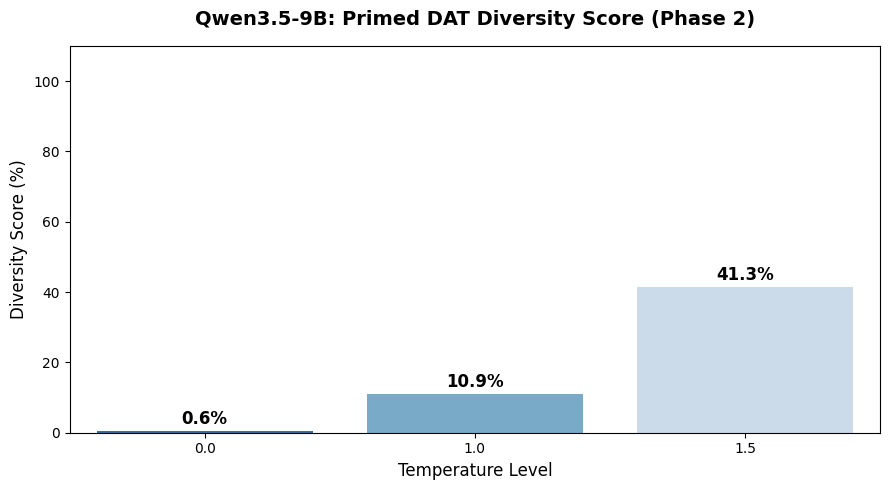

In [38]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from IPython.display import display

# Path adjusted for the Qwen3.5-9B output directory
MAIN_PATH = "/Users/precioux/Desktop/Projects/Creativity/code/Server/Fractals/results/Qwen3.5-9B/main_results.jsonl"

print("Qwen3.5-9B: Phase 2 (Primed DAT) - Word Diversity Analysis\n" + "="*60)

if Path(MAIN_PATH).exists():
    df_main = pd.read_json(MAIN_PATH, lines=True)
    
    # Filter and extract exactly 10 words for valid DAT runs in Phase 2
    def get_valid_words(parsed_data):
        if isinstance(parsed_data, dict) and 'words' in parsed_data:
            if isinstance(parsed_data['words'], list) and len(parsed_data['words']) == 10:
                return [str(w).strip().lower() for w in parsed_data['words']]
        return None

    df_main['valid_words'] = df_main['dat_parsed'].apply(get_valid_words)
    df_success = df_main[df_main['valid_words'].notnull()].copy()
    
    analysis_results = []
    temperatures = sorted(df_success['temperature'].unique())
    diversity_scores = []
    
    for temp in temperatures:
        temp_df = df_success[df_success['temperature'] == temp]
        total_valid_runs = len(temp_df)
        
        all_words = []
        for word_list in temp_df['valid_words']:
            all_words.extend(word_list)
            
        total_words = len(all_words)
        unique_words = len(set(all_words))
        
        # Calculate Diversity Score for Phase 2
        diversity_score = (unique_words / total_words * 100) if total_words > 0 else 0
        diversity_scores.append(diversity_score)
        
        analysis_results.append({
            "Temperature": temp,
            "Valid Runs": total_valid_runs,
            "Total Words": total_words,
            "Unique Words": unique_words,
            "Diversity Score (%)": f"{diversity_score:.1f}%"
        })

    # ==========================================
    # Display the Summary Table
    # ==========================================
    df_analysis = pd.DataFrame(analysis_results)
    styled_df = df_analysis.style.set_properties(**{'text-align': 'center'}).set_table_styles(
        [dict(selector='th', props=[('text-align', 'center'), ('font-weight', 'bold'), ('background-color', '#2980b9'), ('color', 'white')])]
    )
    display(styled_df)
    
    # ==========================================
    # Plotting the Bar Chart
    # ==========================================
    plt.style.use('default')
    plt.figure(figsize=(9, 5))
    
    ax = sns.barplot(x=temperatures, y=diversity_scores, palette="Blues_r")
    
    plt.title('Qwen3.5-9B: Primed DAT Diversity Score (Phase 2)', fontsize=14, fontweight='bold', pad=15)
    plt.xlabel('Temperature Level', fontsize=12)
    plt.ylabel('Diversity Score (%)', fontsize=12)
    plt.ylim(0, 110)
    
    for i, score in enumerate(diversity_scores):
        ax.text(i, score + 2, f"{score:.1f}%", ha='center', fontsize=12, fontweight='bold')
        
    plt.tight_layout()
    plt.show()

else:
    print(f"ERROR: Could not find the file at {MAIN_PATH}")

## All Models

Cross-Model Comparison: DAT Baseline (Phase 1)

--- Baseline Word Diversity (%) ---


,Temp 0.0,Temp 1.0,Temp 1.5
Model,,,
Claude Opus 4.7,37.0%,40.0%,39.0%
GPT-5.4,36.0%,36.0%,41.0%
Gemini 3.1 Pro,31.0%,62.0%,62.0%
Gemma 4,10.0%,37.0%,47.0%
Mistral Small 4,32.0%,56.0%,62.0%
Qwen3.5-9B,30.0%,56.0%,0.0%


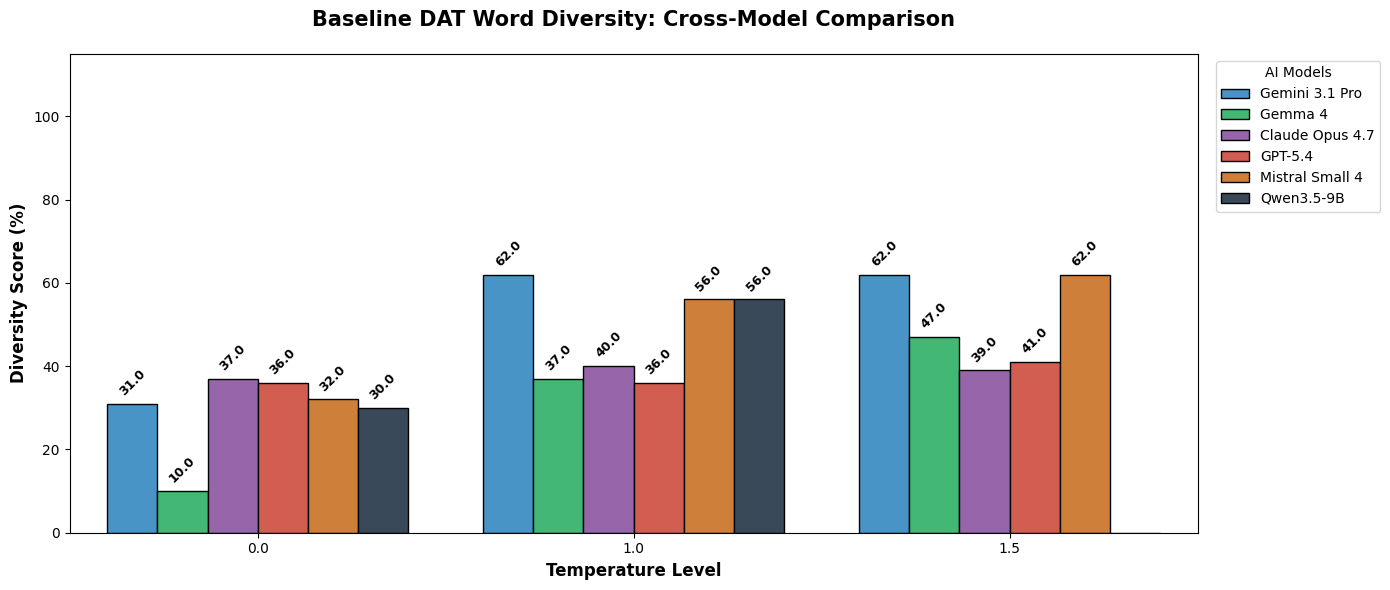

In [39]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from IPython.display import display

# ==========================================
# Configuration: Define models and paths
# ==========================================
BASE_DIR = Path("/Users/precioux/Desktop/Projects/Creativity/code/Server/Fractals/results")

MODELS = {
    "Gemini 3.1 Pro": BASE_DIR / "Gemini-3.1-Pro/dat_baseline_results.jsonl",
    "Gemma 4": BASE_DIR / "Gemma3-26b/dat_baseline_results.jsonl",
    "Claude Opus 4.7": BASE_DIR / "Claude-Opus-4-7/dat_baseline_results.jsonl",
    "GPT-5.4": BASE_DIR / "GPT-5.4/dat_baseline_results.jsonl",
    "Mistral Small 4": BASE_DIR / "Mistral-Small-4/dat_baseline_results.jsonl",
    "Qwen3.5-9B": BASE_DIR / "Qwen3.5-9B/dat_baseline_results.jsonl"
}

PALETTE = {
    "Gemini 3.1 Pro": "#3498db",  # Blue
    "Gemma 4": "#2ecc71",         # Green
    "Claude Opus 4.7": "#9b59b6", # Purple
    "GPT-5.4": "#e74c3c",         # Red
    "Mistral Small 4": "#e67e22", # Orange
    "Qwen3.5-9B": "#34495e"       # Navy/Slate
}

print("Cross-Model Comparison: DAT Baseline (Phase 1)\n" + "="*70)

def check_success(parsed_data):
    if isinstance(parsed_data, dict) and 'words' in parsed_data:
        if isinstance(parsed_data['words'], list) and len(parsed_data['words']) == 10:
            return True
    return False

all_data = []

for model_name, path in MODELS.items():
    if not path.exists():
        print(f"WARN: File not found for {model_name} at {path}")
        continue
        
    df = pd.read_json(path, lines=True)
    df['is_successful'] = df['dat_parsed'].apply(check_success)
    
    for temp in sorted(df['temperature'].unique()):
        temp_df = df[(df['temperature'] == temp) & (df['is_successful'] == True)]
        
        all_words = []
        for words_list in temp_df['dat_parsed'].apply(lambda x: x['words']):
            all_words.extend([str(w).strip().lower() for w in words_list])
            
        total = len(all_words)
        unique = len(set(all_words))
        score = (unique / total * 100) if total > 0 else 0
        
        all_data.append({
            "Model": model_name,
            "Temperature": temp,
            "Diversity Score (%)": score
        })

if all_data:
    df_compare = pd.DataFrame(all_data)
    
    # Table Display
    pivot_table = df_compare.pivot(index="Model", columns="Temperature", values="Diversity Score (%)")
    pivot_table.columns = [f"Temp {c}" for c in pivot_table.columns]
    
    print("\n--- Baseline Word Diversity (%) ---")
    styled_df = pivot_table.style.set_properties(**{'text-align': 'center'}).set_table_styles(
        [dict(selector='th', props=[('text-align', 'center'), ('font-weight', 'bold'), ('background-color', '#1e272e'), ('color', 'white')])]
    ).format("{:.1f}%")
    display(styled_df)

    # Chart Display
    plt.style.use('default')
    plt.figure(figsize=(14, 6))
    
    ax = sns.barplot(data=df_compare, x='Temperature', y='Diversity Score (%)', hue='Model', palette=PALETTE, edgecolor='black')
    
    plt.title('Baseline DAT Word Diversity: Cross-Model Comparison', fontsize=15, fontweight='bold', pad=20)
    plt.xlabel('Temperature Level', fontsize=12, fontweight='bold')
    plt.ylabel('Diversity Score (%)', fontsize=12, fontweight='bold')
    plt.ylim(0, 115)
    plt.legend(title='AI Models', bbox_to_anchor=(1.01, 1), loc='upper left')
    
    for p in ax.patches:
        height = p.get_height()
        if height > 0:
            ax.annotate(f'{height:.1f}', xy=(p.get_x() + p.get_width() / 2, height),
                        xytext=(0, 4), textcoords="offset points", ha='center', va='bottom', fontsize=9, fontweight='bold', rotation=45)
            
    plt.tight_layout()
    plt.show()
else:
    print("ERROR: No data loaded.")

In [43]:
import pandas as pd
import json
from pathlib import Path

# Paths
RESULTS_DIR = Path("/Users/precioux/Desktop/Projects/Creativity/code/Server/Fractals/results")
METADATA_PATH = "/Users/precioux/Desktop/Projects/Creativity/code/Server/Fractals/new-FD-images/metadata.csv"

# Load metadata
df_meta = pd.read_csv(METADATA_PATH)
# Ensure filename matching (assuming 'file' column in results matches 'filename' in meta)
df_meta['filename'] = df_meta['filename'].astype(str)

def evaluate_model_accuracy(model_name, results_file):
    if not results_file.exists(): return None
    
    df_res = pd.read_json(results_file, lines=True)
    results = []
    
    for _, row in df_res.iterrows():
        img_name = row['file']
        meta_row = df_meta[df_meta['filename'] == img_name]
        
        if meta_row.empty: continue
        
        # Ground Truth from metadata (assuming a 'label' or 'category' column exists)
        # Note: You may need to adjust 'ground_truth_label' based on your CSV structure
        ground_truth = str(meta_row.iloc[0]['ground_truth_label']).lower()
        
        parsed = row['fractal_parsed']
        if parsed and 'percepts' in parsed:
            percepts = [p['label'].lower() for p in parsed['percepts']]
            # Check if ground truth was found among the percepts
            match = ground_truth in percepts
            results.append({'Model': model_name, 'Match': match})
            
    df_eval = pd.DataFrame(results)
    acc = df_eval['Match'].mean() * 100
    return acc

# Run evaluation for all models
report = []
for model_name, paths in MODELS_MAIN.items(): # Using previous dictionary
    acc = evaluate_model_accuracy(model_name, paths['main'])
    report.append({'Model': model_name, 'Accuracy (%)': acc})

df_report = pd.DataFrame(report).sort_values(by='Accuracy (%)', ascending=False)
display(df_report)

FileNotFoundError: [Errno 2] No such file or directory: '/Users/precioux/Desktop/Projects/Creativity/code/Server/Fractals/new-FD-images/metadata.csv'